# Plot Snow Data
## UA Snow Data
https://climate.arizona.edu/data/UA_SWE/DailyData_800m/

In [10]:
import xarray as xr
import matplotlib.pyplot as plt

# path to your file
fp = "../map/snow/UA_SWE_Depth_800m_v1_20221201_stable.nc"

# open dataset
ds = xr.open_dataset(fp)

# basic info
print(ds)              # overview (dims, coords, variables)
print(ds.data_vars)    # variables only
print(ds.coords)       # coordinates


<xarray.Dataset> Size: 175MB
Dimensions:   (lat: 3105, lon: 7025, time: 1, time_str_len: 11)
Coordinates:
  * lat       (lat) float32 12kB 24.07 24.08 24.08 24.09 ... 49.92 49.92 49.93
  * lon       (lon) float32 28kB -125.0 -125.0 -125.0 ... -66.5 -66.49 -66.48
  * time      (time) datetime64[ns] 8B 2022-12-01
Dimensions without coordinates: time_str_len
Data variables:
    crs       |S1 1B ...
    time_str  (time_str_len, time) |S1 11B ...
    SWE       (time, lat, lon) float32 87MB ...
    DEPTH     (time, lat, lon) float32 87MB ...
Data variables:
    crs       |S1 1B ...
    time_str  (time_str_len, time) |S1 11B ...
    SWE       (time, lat, lon) float32 87MB ...
    DEPTH     (time, lat, lon) float32 87MB ...
Coordinates:
  * lat      (lat) float32 12kB 24.07 24.08 24.08 24.09 ... 49.92 49.92 49.93
  * lon      (lon) float32 28kB -125.0 -125.0 -125.0 ... -66.5 -66.49 -66.48
  * time     (time) datetime64[ns] 8B 2022-12-01


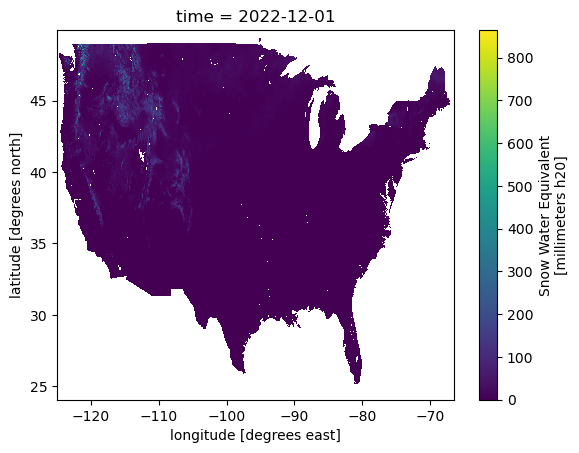

In [11]:
ds["SWE"].isel(time=0).plot()


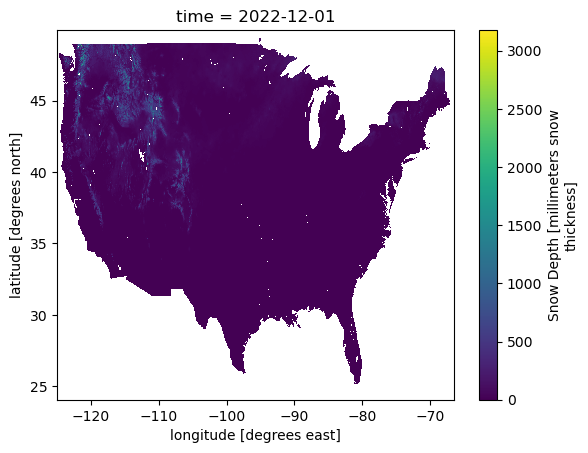

In [13]:
ds["DEPTH"].isel(time=0).plot()


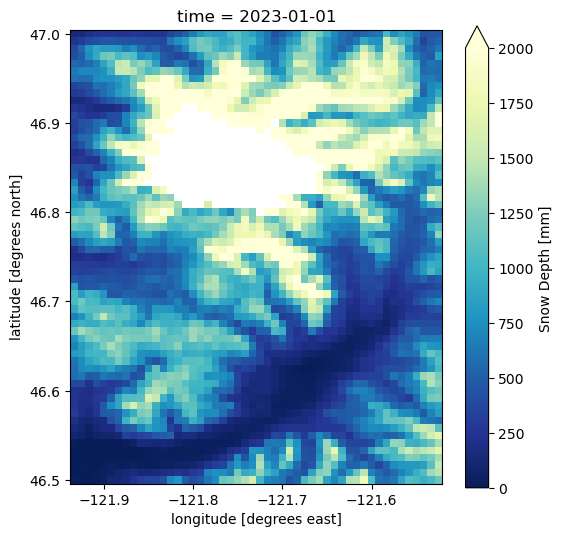

In [ ]:
# select your region of interest
ds_roi = ds["DEPTH"].isel(time=0).sel(
    # lat=slice(46.707552778, 46.993199454),
    lat=slice(46.5, 47),
    lon=slice(-121.936980556, -121.521062714)
)
# plot
fig, ax = plt.subplots(figsize=(6,6))
ds_roi.plot(ax=ax, cmap='YlGnBu_r', vmin=0, vmax=2000, cbar_kwargs={"label": "Snow Depth [mm]"})
ax.set_aspect('equal')  # ensures correct geographic proportions
plt.show()

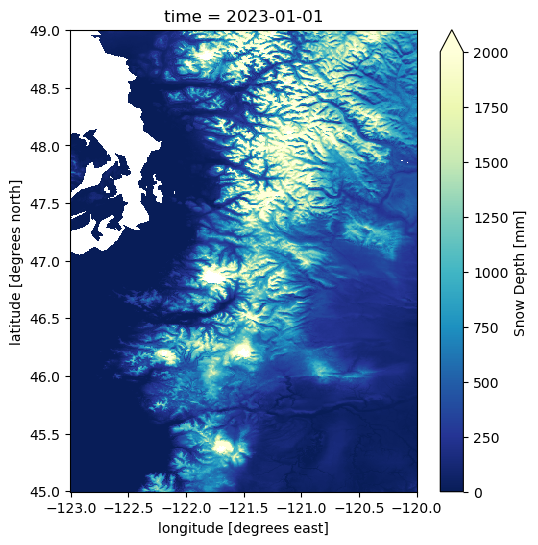

In [ ]:
# select your region of interest
ds_roi = ds["DEPTH"].isel(time=0).sel(
    lat=slice(45., 49.),
    lon=slice(-123., -120.)
)

# plot
fig, ax = plt.subplots(figsize=(6,6))
ds_roi.plot(ax=ax, cmap='YlGnBu_r', vmin=0, vmax=2000, cbar_kwargs={"label": "Snow Depth [mm]"})
ax.set_aspect('equal')  # ensures correct geographic proportions
plt.show()

### Cut the data and save the one hydrological year in one file

In [ ]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Paths
# -----------------------------
input_folder = Path("../map/snow")
output_file = Path("../map/snow/SWE_cropped_merged.nc")

# -----------------------------
# 2️⃣ Region of interest
# -----------------------------
lat_slice = slice(45., 49.)
lon_slice = slice(-123., -120.)

# -----------------------------
# 3️⃣ Load, crop, and merge
# -----------------------------
# get sorted list of NetCDF files
files = sorted(input_folder.glob("*.nc"))

# loop through files and crop
cropped_datasets = []
for fp in files:
    ds = xr.open_dataset(fp)
    
    # crop region
    ds_roi = ds.sel(lat=lat_slice, lon=lon_slice)
    
    # append to list for merging
    cropped_datasets.append(ds_roi)

# merge along 'time'
if len(cropped_datasets) == 1:
    ds_merged = cropped_datasets[0]
else:
    ds_merged = xr.concat(cropped_datasets, dim='time')

# -----------------------------
# 4️⃣ Save merged file
# -----------------------------
ds_merged.to_netcdf(output_file)
print(f"Merged cropped file saved to: {output_file}")


Merged cropped file saved to: ../map/snow/SWE_cropped_merged.nc


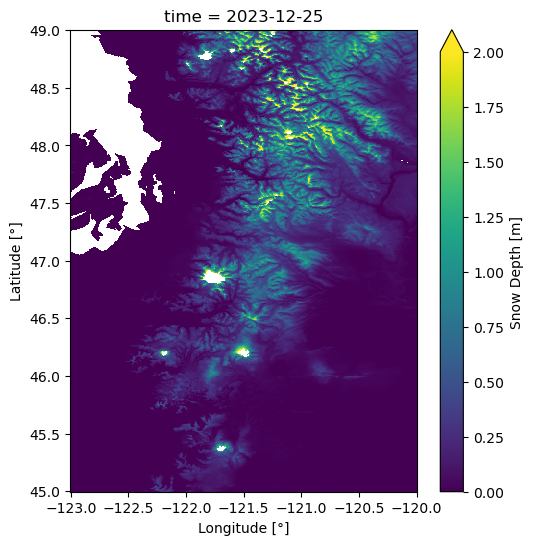

In [66]:
# -----------------------------
# 5️⃣ Load merged file later
# -----------------------------
ds_loaded = xr.open_dataset(output_file)

# -----------------------------
# 6️⃣ Plot selected time step
# -----------------------------
# time index (0 for first day)
time_idx = 450
(ds_loaded["DEPTH"].isel(time=time_idx)/1000).plot(figsize=(6,6), vmin=0, vmax=2, cbar_kwargs={"label": "Snow Depth [m]"})
plt.xlabel("Longitude [°]")
plt.ylabel("Latitude [°]")
plt.gca().set_aspect('equal')
plt.show()


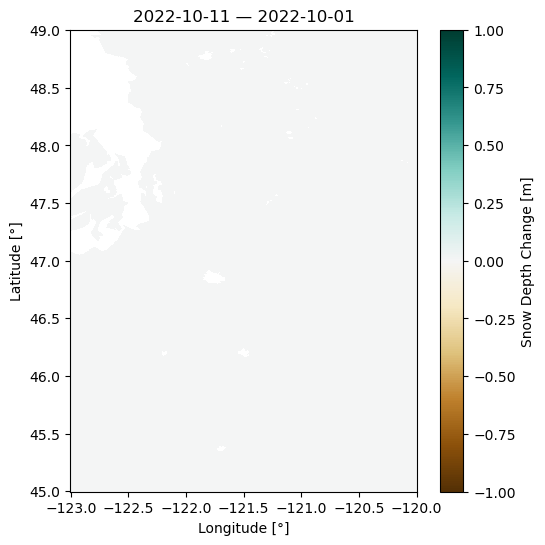

In [77]:
# choose time steps
time_idx1 = 0
time_idx2 = 10

# get actual dates from time coordinate
date1 = ds_loaded["time"].isel(time=time_idx1).values.astype("M8[D]")  # convert to numpy date
date2 = ds_loaded["time"].isel(time=time_idx2).values.astype("M8[D]")

# compute difference (in meters)
diff = (ds_loaded["DEPTH"].isel(time=time_idx2) - ds_loaded["DEPTH"].isel(time=time_idx1)) / 1000

# plot difference
diff.plot(
    figsize=(6,6),
    cmap="BrBG",         # blue for negative, red for positive changes
    vmin=-1, vmax=1,    # adjust to a reasonable range for snow depth change
    extend = "neither",
    cbar_kwargs={"label": "Snow Depth Change [m]"}
)
plt.xlabel("Longitude [°]")
plt.ylabel("Latitude [°]")
plt.gca().set_aspect('equal')
plt.title(f"{date2} — {date1}")
plt.show()


### Produce and save GIF

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import imageio
from pathlib import Path
from io import BytesIO

# -----------------------------
# Load merged file
# -----------------------------
output_file = Path("../map/snow/SWE_cropped_merged.nc")
ds_loaded = xr.open_dataset(output_file)

In [ ]:
# -----------------------------
# GIF settings
# -----------------------------
start_idx = 350
end_idx = len(ds_loaded["time"])

# optional: colormap limits
vmin = 0
vmax = 2

# -----------------------------
# Create GIF frames
# -----------------------------
frames = []

for t in range(start_idx, end_idx):
    fig, ax = plt.subplots(figsize=(6,6))
    
    (ds_loaded["DEPTH"].isel(time=t)/1000).sel(
        lat=slice(46.6, 47),
        lon=slice(-122., -121.5)
    ).plot(
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        extend = "neither",
        cbar_kwargs={"label": "Snow Depth [m]"}
    )
    ax.set_xlabel("Longitude [°]")
    ax.set_ylabel("Latitude [°]")
    ax.set_aspect('equal')
    ax.set_title(str(ds_loaded["time"].isel(time=t).values.astype("M8[D]")))
    
    # save figure to a BytesIO buffer
    fig.savefig(f"/Users/koepflma/Desktop/cascade/MtRainier/weather/snow_gif/UA_snow_{t}.png", dpi=150)



In [ ]:
# -----------------------------
# Vectorized difference
# -----------------------------
depth_m = ds_loaded["DEPTH"] / 1000
diff_all = depth_m.diff(dim="time")
diff_all = diff_all.assign_coords(time=ds_loaded["time"][1:])

# -----------------------------
# GIF settings
# -----------------------------
gif_file = Path("../map/snow/snow_depth_diff.gif")
vmax = 1
vmin = -vmax
frames = []

# -----------------------------
# Hydrological year 2023/2024
# -----------------------------
start_idx = 350
end_idx = len(ds_loaded["time"])

# -----------------------------
# Loop over time and create frames
# -----------------------------
# for t in range(len(diff_all["time"])):
for t in range(start_idx, end_idx):
    fig, ax = plt.subplots(figsize=(6,6))

    # set background color to light gray
    ax.set_facecolor("lightgray")
    
    diff_all.isel(time=t).plot(
        ax=ax,
        cmap="BrBG",  # use custom colormap
        vmin=vmin, vmax=vmax,
        extend = "neither",
        cbar_kwargs={"label": "Snow Depth Change [m]"}
    )
    ax.set_xlabel("Longitude [°]")
    ax.set_ylabel("Latitude [°]")
    ax.set_aspect("equal")
    
    date = diff_all["time"].isel(time=t).values.astype("M8[D]")
    ax.set_title(f"Daily Change: {date}")
    
    # save figure to buffer
    fig.savefig(f"/Users/koepflma/Desktop/cascade/MtRainier/weather/snow_diff_gif/UA_snow_{t}.png", dpi=150)



GIF saved as snow_depth_diff_vectorized.gif


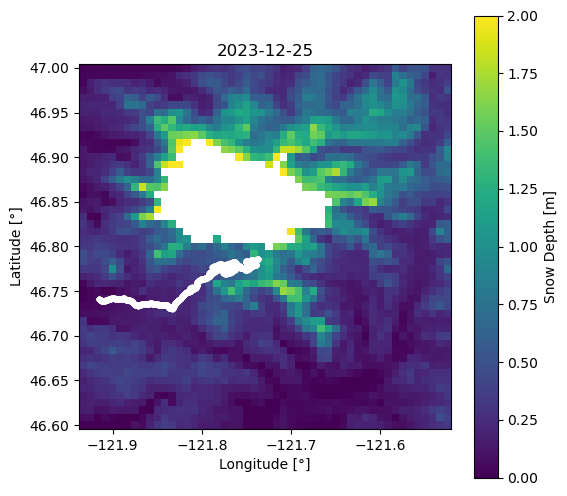

In [89]:

t = 450
fig, ax = plt.subplots(figsize=(6,6))

(ds_loaded["DEPTH"].isel(time=t)/1000).sel(
    lat=slice(46.6, 47),
    lon=slice(-121.936980556, -121.521062714)
    ).plot(
        ax=ax,
        vmin=0,
        vmax=2,
        extend = "neither",
        cbar_kwargs={"label": "Snow Depth [m]"}
)

x = df['Longitude [°]']
y = df['Latitude [°]']

# All channels: small white dots
ax.plot(x, y ,marker='.', color='white')


ax.set_xlabel("Longitude [°]")
ax.set_ylabel("Latitude [°]")
ax.set_aspect('equal')
ax.set_title(str(ds_loaded["time"].isel(time=t).values.astype("M8[D]")))
ax.set_aspect('equal')

### Produce and save GIF with gmt

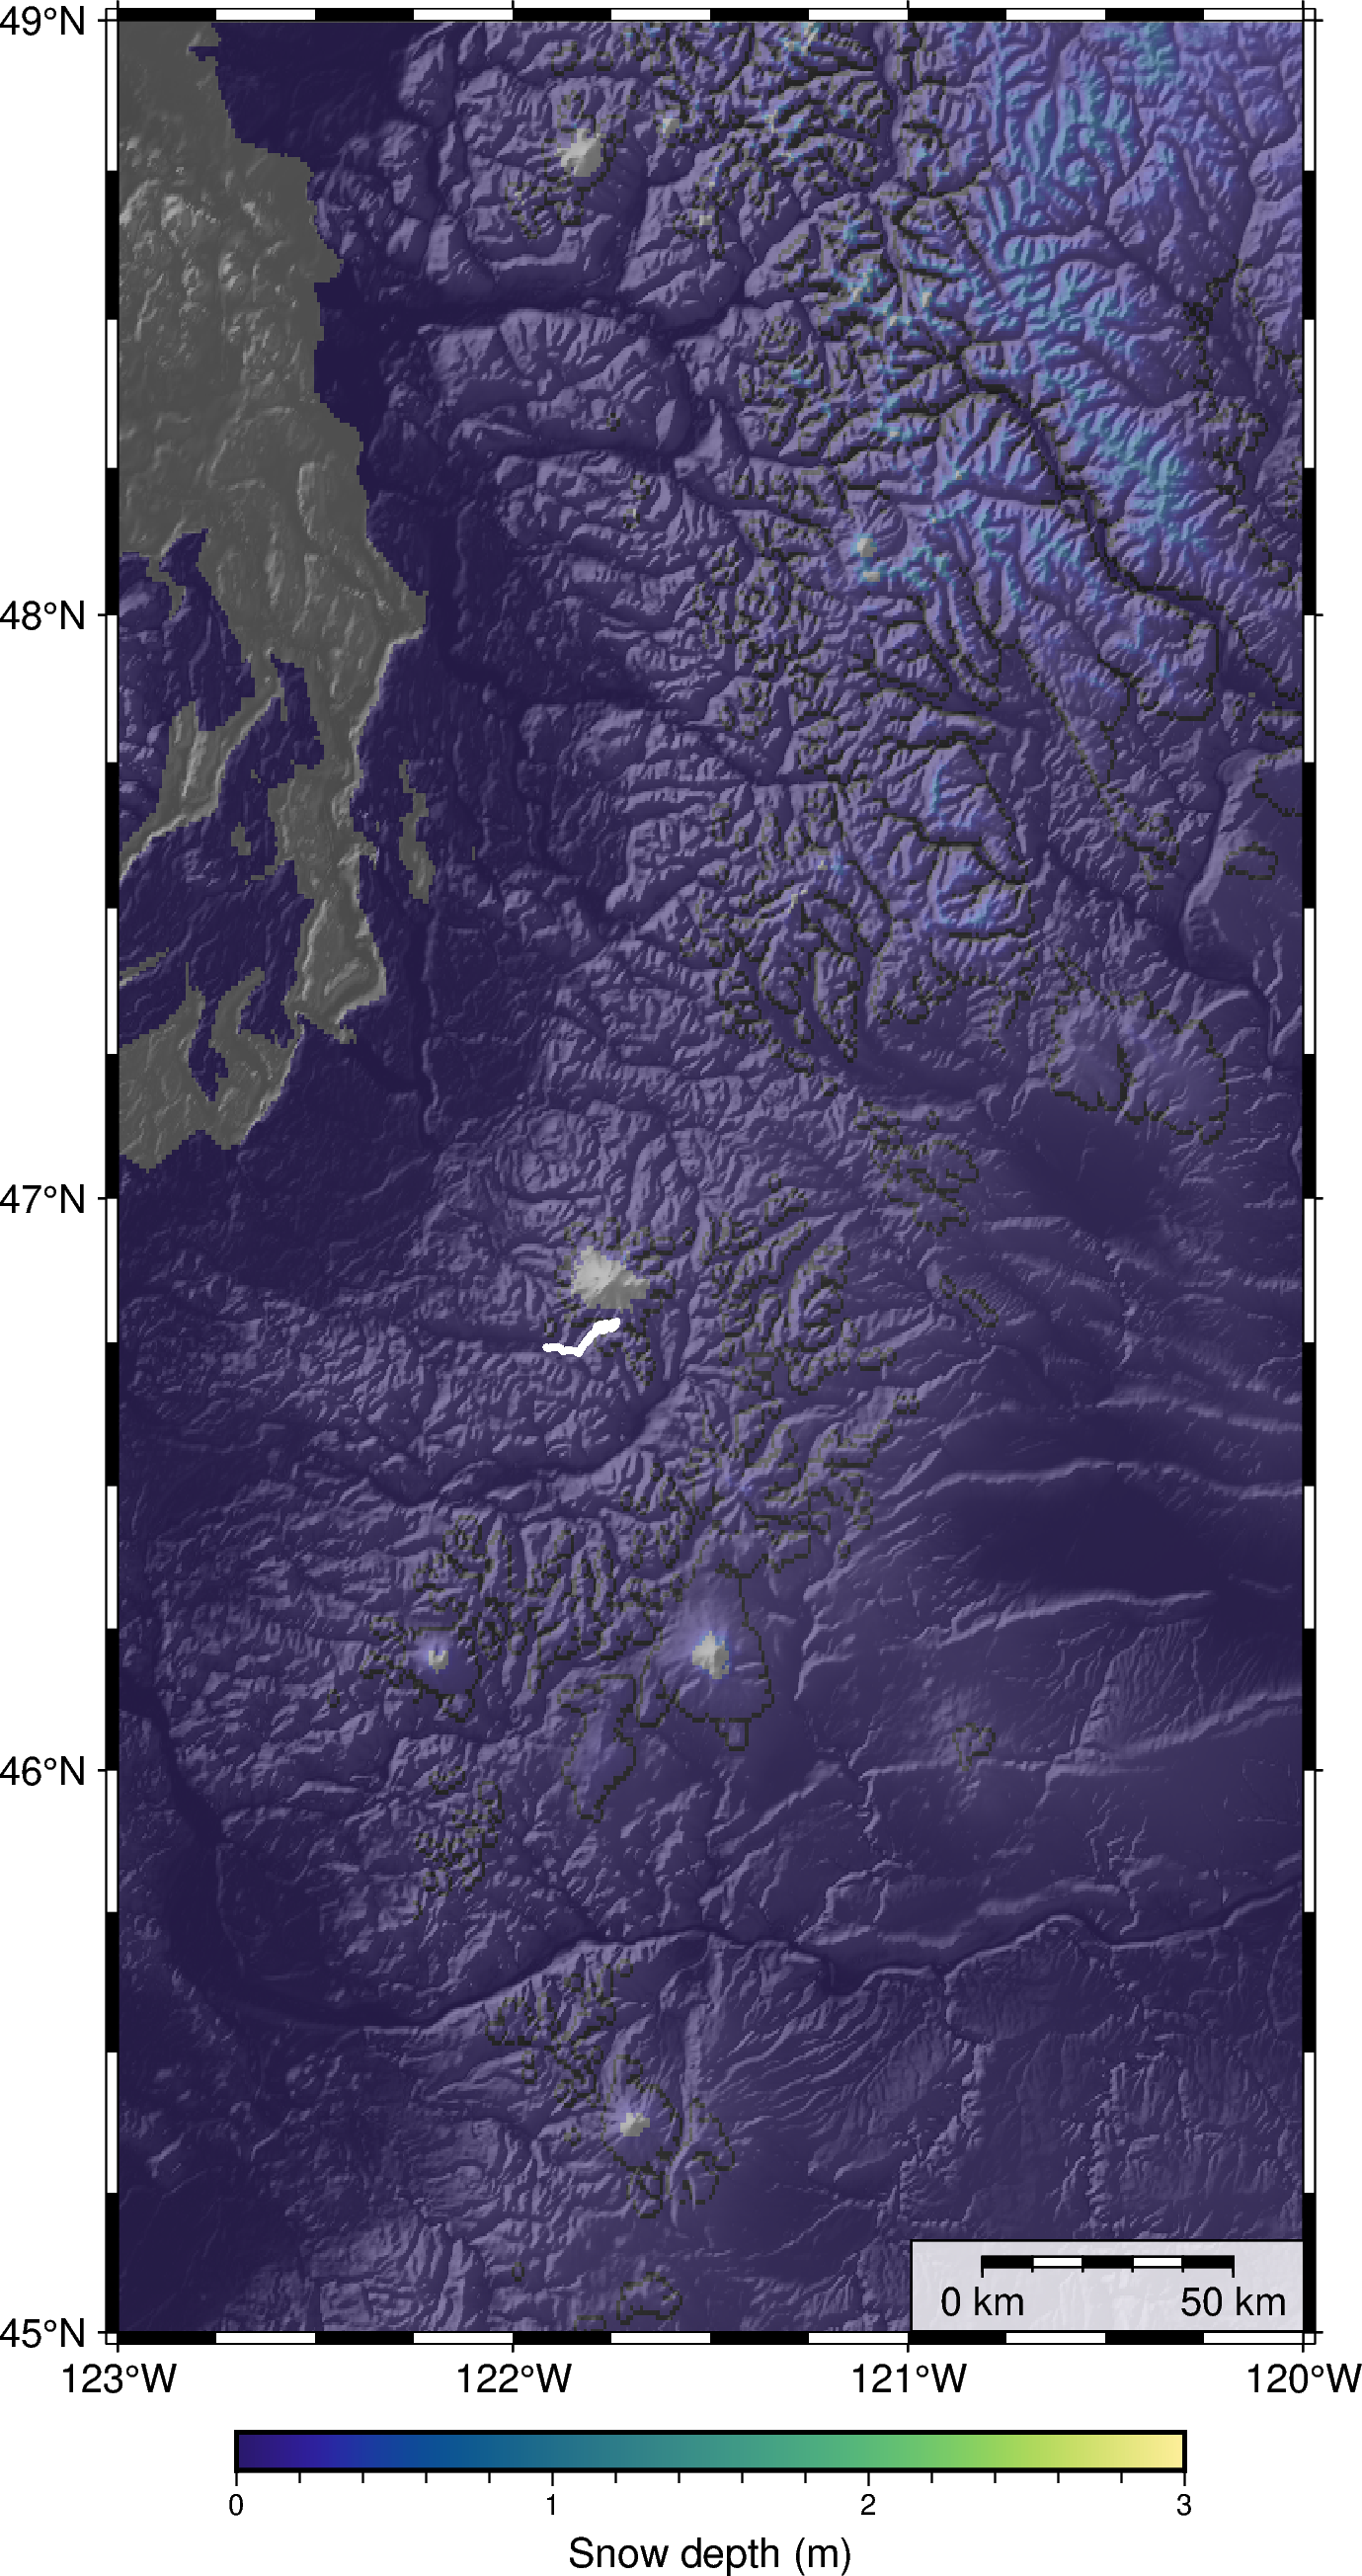

In [ ]:
import pygmt
import pygmt.datasets
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import imageio
from io import BytesIO
from pathlib import Path
import tempfile
from tqdm import tqdm
import numpy as np
import pandas as pd
import scipy
import datetime

# -----------------------------
# Load snow depth data
# -----------------------------
# ds_loaded: xarray DataArray with dims ['lat','lon'] (or ['time','lat','lon'])
df = pd.read_csv("../fiber_rout/Paradise2NisquallyEntrace_Channels.csv")
df = df.dropna(subset=["Latitude [°]", "Longitude [°]"])

output_file = Path("../map/snow/SWE_cropped_merged.nc")
ds_loaded = xr.open_dataset(output_file)


In [ ]:
# pick one time slice for plotting
snow = ds_loaded["DEPTH"].isel(time=400) / 1000  # convert to meters

# Save as temporary NetCDF for PyGMT
snow_file = "./data/weather/snow/snow_temp.nc"
snow.to_netcdf(snow_file)

# -----------------------------
# Define region and projection
# -----------------------------
xmin, xmax = snow.lon.min().item(), snow.lon.max().item()
ymin, ymax = snow.lat.min().item(), snow.lat.max().item()
region = [xmin, xmax, ymin, ymax]

projection = "M4i"  # 4 inch map width

# -----------------------------
# Load DEM (03s ~ 90 m)
# -----------------------------
dem = pygmt.datasets.load_earth_relief(resolution="15s", region=region)

# Compute hillshade
hillshade = pygmt.grdgradient(dem, azimuth=315, normalize="t1")

# -----------------------------
# Create figure
# -----------------------------
fig = pygmt.Figure()

# Base hillshade
fig.grdimage(
    grid=dem,
    region=region,
    projection=projection,
    shading=hillshade,
    cmap="gray"
)

# Overlay snow depth (transparent)
# pygmt.makecpt(cmap="ice", series=[0, 3])
pygmt.makecpt(cmap="haline", series=[0, 3], reverse=False)

fig.grdimage(
    grid=snow_file,
    region=region,
    projection=projection,
    cmap=True,   # choose your favorite colormap
    transparency=50   # 0-100%, 50% makes snow semi-transparent
)

fig.basemap(
    frame="af"
)


# Optional: add fiber route points
x = df['Longitude [°]']
y = df['Latitude [°]']

# All channels: small white dots
fig.plot(x=x, y=y, style="c0.05c", pen="0.1p,white")

# # Highlight every 500th channel
# df_lbl = df[df['Channel'] % 500 == 0]
# fig.plot(
#     x=df_lbl['Longitude [°]'],
#     y=df_lbl['Latitude [°]'],
#     style="c0.1c",
#     pen="1.0p,black"
# )
fig.colorbar(frame='af+lSnow depth (m)')
# Add map scale
fig.basemap(map_scale="jBR+w50k+o0.6c/0.47c+f+ukm", box="+gwhite@20+p0.5p,black")
fig.show()
# Save figure
# fig.savefig("snow_hillshade_fiber.png", dpi=300)


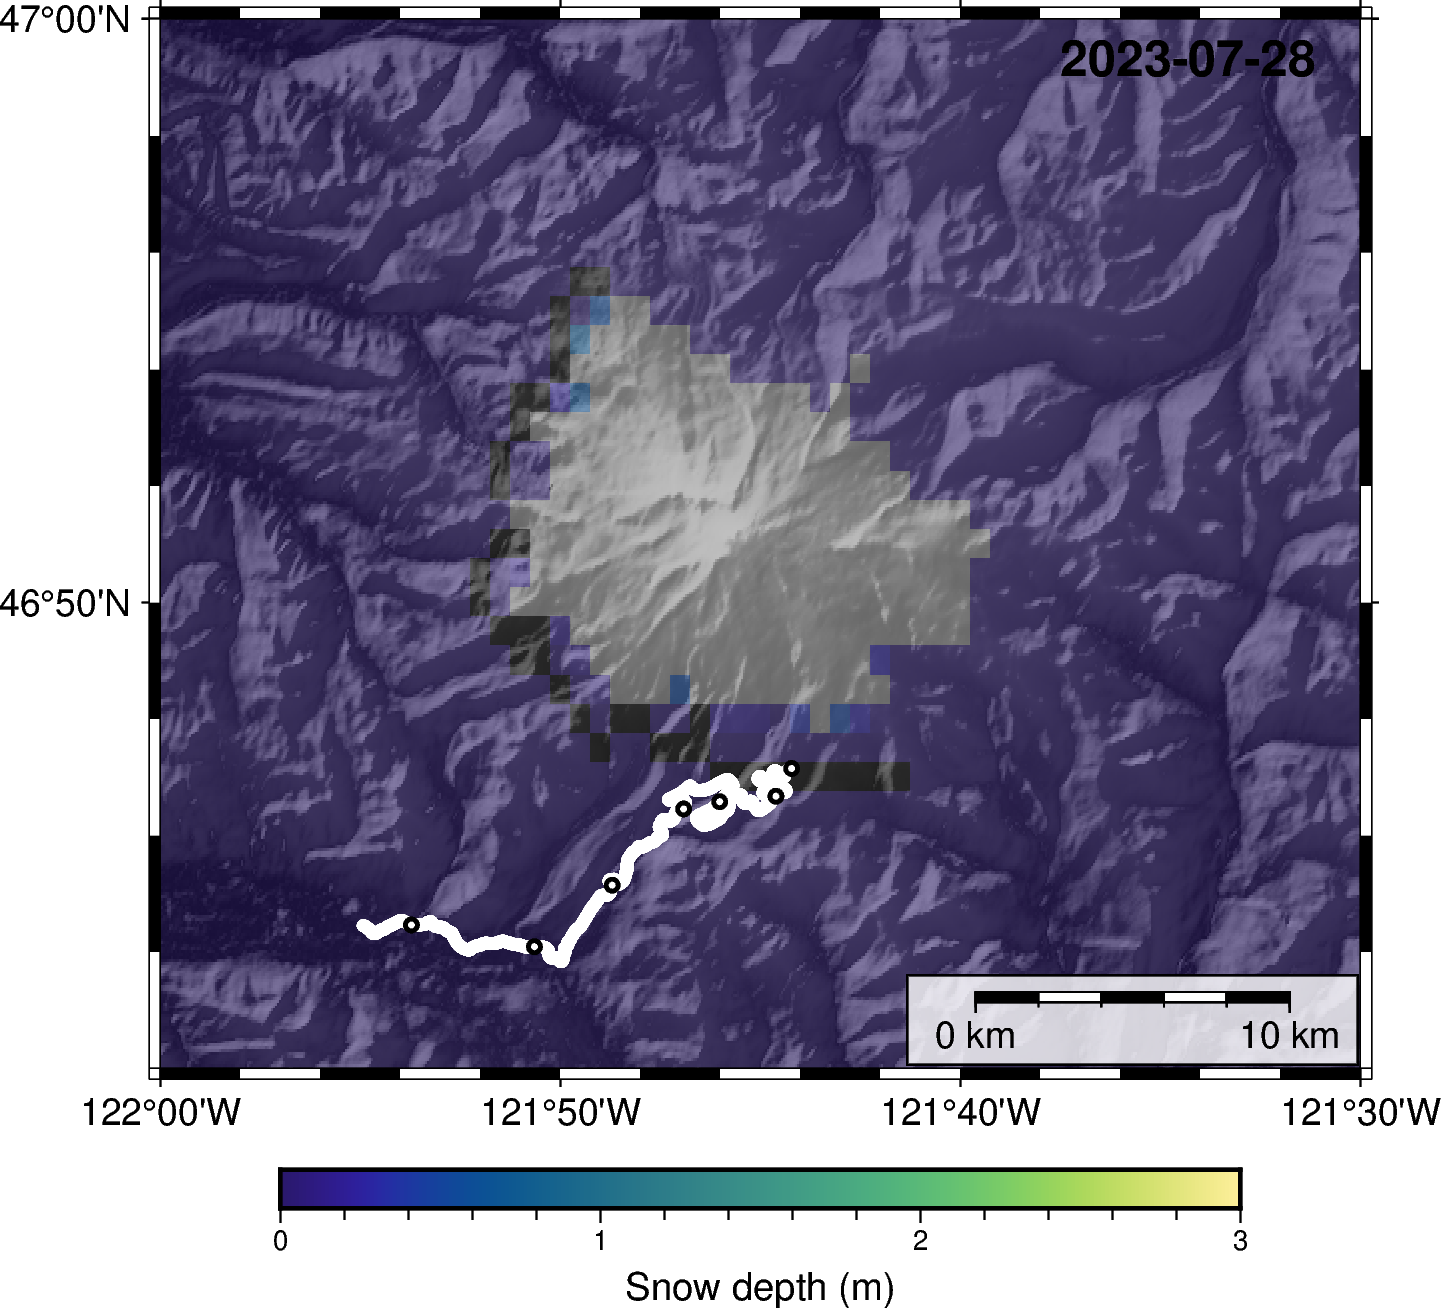

In [ ]:
time_idx = 300

# pick one time slice for plotting
snow = ds_loaded["DEPTH"].isel(time=time_idx).sel(
    lat=slice(46.7, 47),
    lon=slice(-122, -121.5)) / 1000  # convert to meters

# Get the datetime for the selected index
date_str = str(ds_loaded["time"].isel(time=time_idx).values.astype("M8[D]"))  # "YYYY-MM-DD"

# Save as temporary NetCDF for PyGMT
snow_file = "./data/weather/snow/snow_temp.nc"
snow.to_netcdf(snow_file)

# -----------------------------
# Define region and projection
# -----------------------------
xmin, xmax = snow.lon.min().item(), snow.lon.max().item()
ymin, ymax = snow.lat.min().item(), snow.lat.max().item()
region = [xmin, xmax, ymin, ymax]

projection = "M4i"  # 4 inch map width

# -----------------------------
# Load DEM (03s ~ 90 m)
# -----------------------------
dem = pygmt.datasets.load_earth_relief(resolution="03s", region=region)

# Compute hillshade
hillshade = pygmt.grdgradient(dem, azimuth=315, normalize="t1")

# -----------------------------
# Create figure
# -----------------------------
fig = pygmt.Figure()

# Base hillshade
fig.grdimage(
    grid=dem,
    region=region,
    projection=projection,
    shading=hillshade,
    cmap="gray"
)

# Overlay snow depth (transparent)
# pygmt.makecpt(cmap="ice", series=[0, 3], reverse=True)
pygmt.makecpt(cmap="haline", series=[0, 3], reverse=False)

fig.grdimage(
    grid=snow_file,
    region=region,
    projection=projection,
    cmap=True,
    transparency=50,
)

fig.basemap(
    frame="af"
)
fig.text(
    text=date_str,
    x=xmax - 0.25*(xmax-xmin),
    y=ymax - 0.02*(ymax-ymin),
    font="12p,Helvetica-Bold,black",
    justify="TL"
)

# Optional: add fiber route points
x = df['Longitude [°]']
y = df['Latitude [°]']

# All channels: small white dots
fig.plot(x=x, y=y, style="c0.1c", pen="0.1p,white")

# Highlight every 500th channel
df_lbl = df[df['Channel'] % 500 == 0]
fig.plot(
    x=df_lbl['Longitude [°]'],
    y=df_lbl['Latitude [°]'],
    style="c0.1c",
    pen="1.0p,black"
)
fig.colorbar(frame='af+lSnow depth (m)')
# Add map scale
fig.basemap(map_scale="jBR+w10k+o0.6c/0.47c+f+ukm", box="+gwhite@20+p0.5p,black")
fig.show()



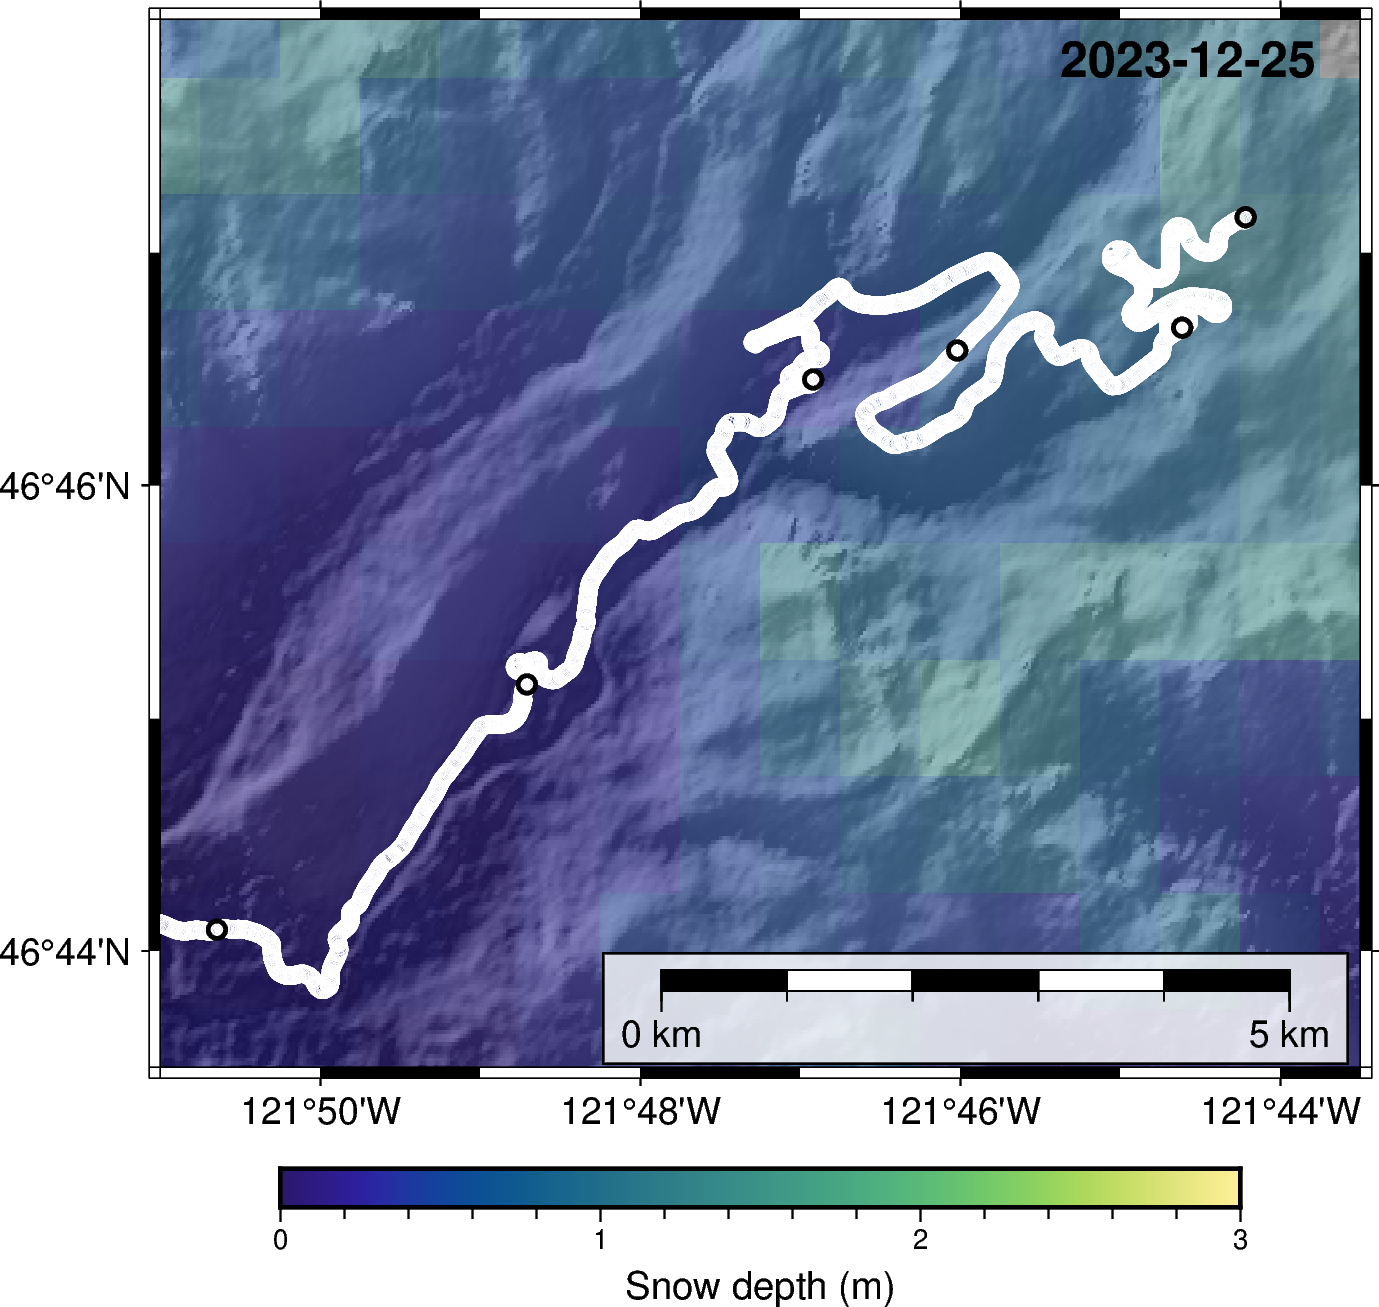

In [ ]:
time_idx = 450

# pick one time slice for plotting
snow = ds_loaded["DEPTH"].isel(time=time_idx).sel(
    lat=slice(46.72, 46.8),
    lon=slice(-121.85, -121.72)) / 1000  # convert to meters

# Get the datetime for the selected index
date_str = str(ds_loaded["time"].isel(time=time_idx).values.astype("M8[D]"))  # "YYYY-MM-DD"

# Save as temporary NetCDF for PyGMT
snow_file = "./data/weather/snow/snow_temp.nc"
snow.to_netcdf(snow_file)

# -----------------------------
# Define region and projection
# -----------------------------
xmin, xmax = snow.lon.min().item(), snow.lon.max().item()
ymin, ymax = snow.lat.min().item(), snow.lat.max().item()
region = [xmin, xmax, ymin, ymax]

projection = "M4i"  # 4 inch map width

# -----------------------------
# Load DEM (03s ~ 90 m)
# -----------------------------
dem = pygmt.datasets.load_earth_relief(resolution="01s", region=region)

# Compute hillshade
hillshade = pygmt.grdgradient(dem, azimuth=315, normalize="t1")

# -----------------------------
# Create figure
# -----------------------------
fig = pygmt.Figure()

# Base hillshade
fig.grdimage(
    grid=dem,
    region=region,
    projection=projection,
    shading=hillshade,
    cmap="gray"
)

# Overlay snow depth (transparent)
# pygmt.makecpt(cmap="ice", series=[0, 3], reverse=True)
pygmt.makecpt(cmap="haline", series=[0, 3], reverse=False)

fig.grdimage(
    grid=snow_file,
    region=region,
    projection=projection,
    cmap=True,   # choose your favorite colormap
    transparency=50   # 0-100%, 50% makes snow semi-transparent
)

fig.basemap(
    frame="af"
)
fig.text(
    text=date_str,
    x=xmax - 0.25*(xmax-xmin),
    y=ymax - 0.02*(ymax-ymin),
    font="12p,Helvetica-Bold,black",
    justify="TL"
)

# Optional: add fiber route points
x = df['Longitude [°]']
y = df['Latitude [°]']

# All channels: small white dots
fig.plot(x=x, y=y, style="c0.15c", pen="0.1p,white")

# Highlight every 500th channel
df_lbl = df[df['Channel'] % 500 == 0]
fig.plot(
    x=df_lbl['Longitude [°]'],
    y=df_lbl['Latitude [°]'],
    style="c0.15c",
    pen="1.0p,black"
)
fig.colorbar(frame='af+lSnow depth (m)')
# Add map scale
with pygmt.config(MAP_SCALE_HEIGHT="10p"):
    fig.basemap(map_scale="jBR+w5k+o0.6c/0.47c+f+ukm", box="+gwhite@20+p0.5p,black")
fig.show()

In [ ]:
# -----------------------------
# Define GIF output and range
# -----------------------------
gif_file = Path("../map/snow/snow_depth_map_MtRainier_zoom.gif")
start_idx = 350
end_idx = len(ds_loaded["time"])

lat=slice(46.72, 46.8)
lon=slice(-121.85, -121.72)
frames = []

# -----------------------------
# Define region and DEM
# -----------------------------
# small sample slice to get region
sample_snow = ds_loaded["DEPTH"].isel(time=start_idx).sel(
    lat=lat,
    lon=lon) / 1000  # convert to meters

xmin, xmax = sample_snow.lon.min().item(), sample_snow.lon.max().item()
ymin, ymax = sample_snow.lat.min().item(), sample_snow.lat.max().item()
region = [xmin, xmax, ymin, ymax]

# Load DEM once (big, only needs to be done once)
dem = pygmt.datasets.load_earth_relief(resolution="03s", region=region)
hillshade = pygmt.grdgradient(dem, azimuth=315, normalize="t1")

# -----------------------------
# Loop over time to make GIF frames
# -----------------------------
for t_idx in tqdm(range(start_idx, end_idx)):
    # pick time slice
    snow = ds_loaded["DEPTH"].isel(time=t_idx).sel(
        lat=lat,
        lon=lon
    ) / 1000  # meters
    
    # date string
    date_str = str(ds_loaded["time"].isel(time=t_idx).values.astype("M8[D]"))
    
    # save temporary NetCDF for PyGMT
    snow_file = f"./data/weather/snow/snow_temp_{t_idx}.nc"
    snow.to_netcdf(snow_file)
    
    # start PyGMT figure
    fig = pygmt.Figure()
    
    # Base hillshade
    fig.grdimage(
        grid=dem,
        region=region,
        projection="M4i",
        shading=hillshade,
        cmap="gray"
    )
    
    # Overlay snow depth with colormap
    pygmt.makecpt(cmap="haline", series=[0, 3], reverse=False)
    fig.grdimage(
        grid=snow_file,
        region=region,
        projection="M4i",
        cmap=True,
        transparency=50
    )
    
    # Map frame
    fig.basemap(frame="af")
    
    # Date label (top-left)
    fig.text(
        text=date_str,
        x=xmax - 0.25*(xmax-xmin),
        y=ymax - 0.02*(ymax-ymin),
        font="12p,Helvetica-Bold,black",
        justify="TL"
    )
    
    # Fiber points
    x = df['Longitude [°]']
    y = df['Latitude [°]']
    fig.plot(x=x, y=y, style="c0.15c", pen="0.1p,white")
    
    df_lbl = df[df['Channel'] % 500 == 0]
    fig.plot(
        x=df_lbl['Longitude [°]'],
        y=df_lbl['Latitude [°]'],
        style="c0.15c",
        pen="1.0p,black"
    )
    
    # Colorbar
    fig.colorbar(frame='af+lSnow depth (m)')
    
    # Map scale
    with pygmt.config(MAP_SCALE_HEIGHT="10p"):
        fig.basemap(map_scale="jBR+w5k+o0.6c/0.47c+f+ukm", box="+gwhite@20+p0.5p,black")
    
    fig.savefig(f"/Users/koepflma/Desktop/cascade/MtRainier/weather/snow_pygmt_gif/UA_snow_{t}.png", dpi=150)



100%|██████████| 381/381 [01:56<00:00,  3.28it/s]


GIF saved as ../map/snow/snow_depth_map_MtRainier_zoom.gif


### Time vs channel

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import numpy as np
import pandas as pd
import scipy
import datetime

# -----------------------------
# Load snow depth data
# -----------------------------
# ds_loaded: xarray DataArray with dims ['lat','lon'] (or ['time','lat','lon'])
df = pd.read_csv("../fiber_rout/Paradise2NisquallyEntrace_Channels.csv")
df = df.dropna(subset=["Latitude [°]", "Longitude [°]"])

output_file = Path("../map/snow/SWE_cropped_merged.nc")
ds_loaded = xr.open_dataset(output_file)


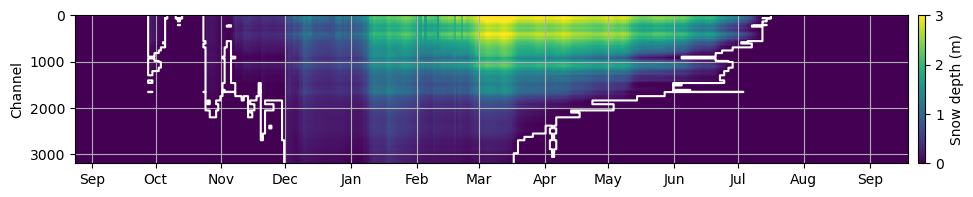

In [48]:
lats = xr.DataArray(df['Latitude [°]'].values, dims="channel")
lons = xr.DataArray(df['Longitude [°]'].values, dims="channel")

plot_param = "DEPTH" # DEPTH or SWE

if plot_param == "DEPTH":
    data = ds_loaded["DEPTH"].interp(lat=lats, lon=lons)/1000  # convert to meters
    mask = data > 0
    label = "Snow depth (m)"
    vmin = 0
    vmax = 3
elif plot_param == "SWE":
    data = ds_loaded["SWE"].interp(lat=lats, lon=lons)/1000  # convert to meters
    mask = data > 0
    label = "SWE (m)"
    vmin = 0
    vmax = 1.25

fig, ax = plt.subplots(figsize=(6.4*2,4.8*0.4))

# --- base SWE image ---
pcm = ax.pcolormesh(
    data.time.values,
    np.arange(len(lats)),
    data.T,
    shading="auto",
    vmin=vmin, vmax=vmax
)

fig.colorbar(pcm, ax=ax, pad=0.01, label=label)

# --- OUTLINE ONLY ---
ax.contour(
    mask.time.values,
    np.arange(len(lats)),
    mask.T.astype(int),   # convert bool → 0/1
    levels=[0.5],                # boundary between false/true
    colors="white",
    linewidths=1.5
)

# formatting
plt.grid()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(datetime.datetime(2023, 8, 24), datetime.datetime(2024, 9, 19))
ax.invert_yaxis()
ax.set_ylabel("Channel")

plt.show()


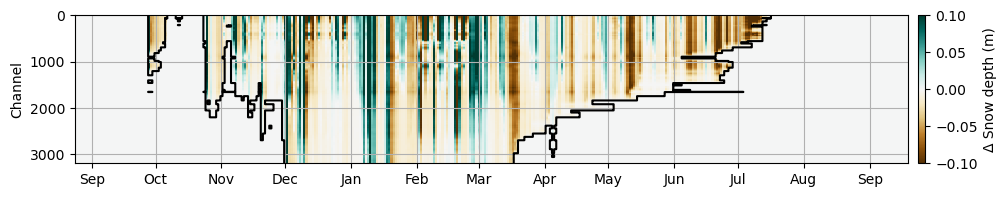

In [51]:
# ---------------------------------
# Interpolate + compute difference
# ---------------------------------
if plot_param == "DEPTH":
    data = ds_loaded["DEPTH"].interp(lat=lats, lon=lons) / 1000
    label = "Δ Snow depth (m)"
    vmin, vmax = -0.1, 0.1
elif plot_param == "SWE":
    data = ds_loaded["SWE"].interp(lat=lats, lon=lons) / 1000
    label = "Δ SWE (m)"
    vmin, vmax = -0.04, 0.04

# keep mask from original
mask = data > 0

# compute time difference but keep same shape
data_vals = data.values
diff_vals = np.diff(data_vals, axis=0)

# prepend NaN row manually (only in data, NOT time)
diff_vals = np.vstack([np.full((1, diff_vals.shape[1]), np.nan), diff_vals])

data_diff = xr.DataArray(
    diff_vals,
    coords=data.coords,
    dims=data.dims
)

fig, ax = plt.subplots(figsize=(6.4*2,4.8*0.4))

pcm = ax.pcolormesh(
    data.time.values,
    np.arange(len(lats)),
    data_diff.T,
    shading="auto",
    cmap="BrBG",
    vmin=vmin,
    vmax=vmax
)

fig.colorbar(pcm, ax=ax, pad=0.01, label=label)

# --- OUTLINE ONLY ---
ax.contour(
    mask.time.values,
    np.arange(len(lats)),
    mask.T.astype(int),   # convert bool → 0/1
    levels=[0.5],                # boundary between false/true
    colors="k",
    linewidths=1.5
)

# formatting
plt.grid()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(datetime.datetime(2023, 8, 24), datetime.datetime(2024, 9, 19))
ax.invert_yaxis()
ax.set_ylabel("Channel")
plt.show()

# Plot Soil Moisture Data
## SMAP
https://nsidc.org/data/nsidc-0779/versions/1

In [2]:
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt

# path to your file
fp = "/Volumes/optoDAS/Rainier/SMAP/NSIDC-0779_EASE2_G1km_SMAP_SM_DS_20230101.tif"

# open dataset
ds = xr.open_dataset(fp, engine="rasterio")

# basic info
print(ds)              # overview (dims, coords, variables)
print(ds.rio.crs)    # coordinate reference system

<xarray.Dataset> Size: 4GB
Dimensions:      (band: 2, x: 34704, y: 14616)
Coordinates:
  * band         (band) int64 16B 1 2
  * x            (x) float64 278kB -1.737e+07 -1.737e+07 ... 1.737e+07 1.737e+07
  * y            (y) float64 117kB 7.314e+06 7.313e+06 ... -7.313e+06 -7.314e+06
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 4GB ...
EPSG:6933


In [3]:
soil_moisture = ds.band_data.sel(band=1)

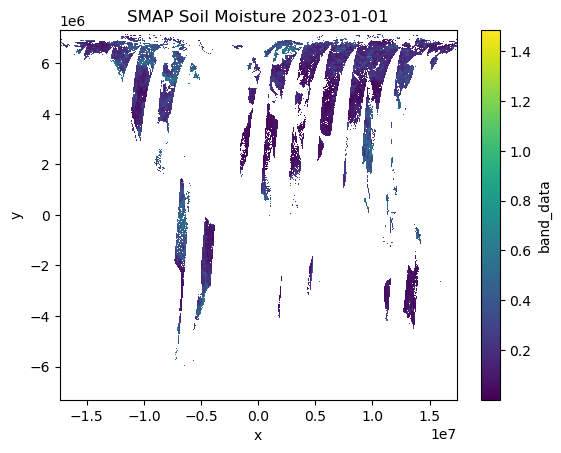

In [18]:
soil_moisture.plot()
plt.title("SMAP Soil Moisture 2023-01-01")
plt.show()

In [24]:
sm_clip = soil_moisture.rio.clip_box(
    minx=-123,
    miny=45,
    maxx=-120,
    maxy=49,
    crs="EPSG:4326"
)

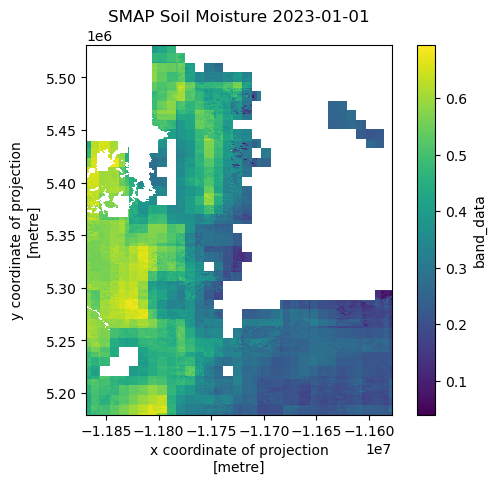

In [25]:
sm_clip.plot()
plt.title("SMAP Soil Moisture 2023-01-01")
plt.gca().set_aspect('equal')
plt.show()

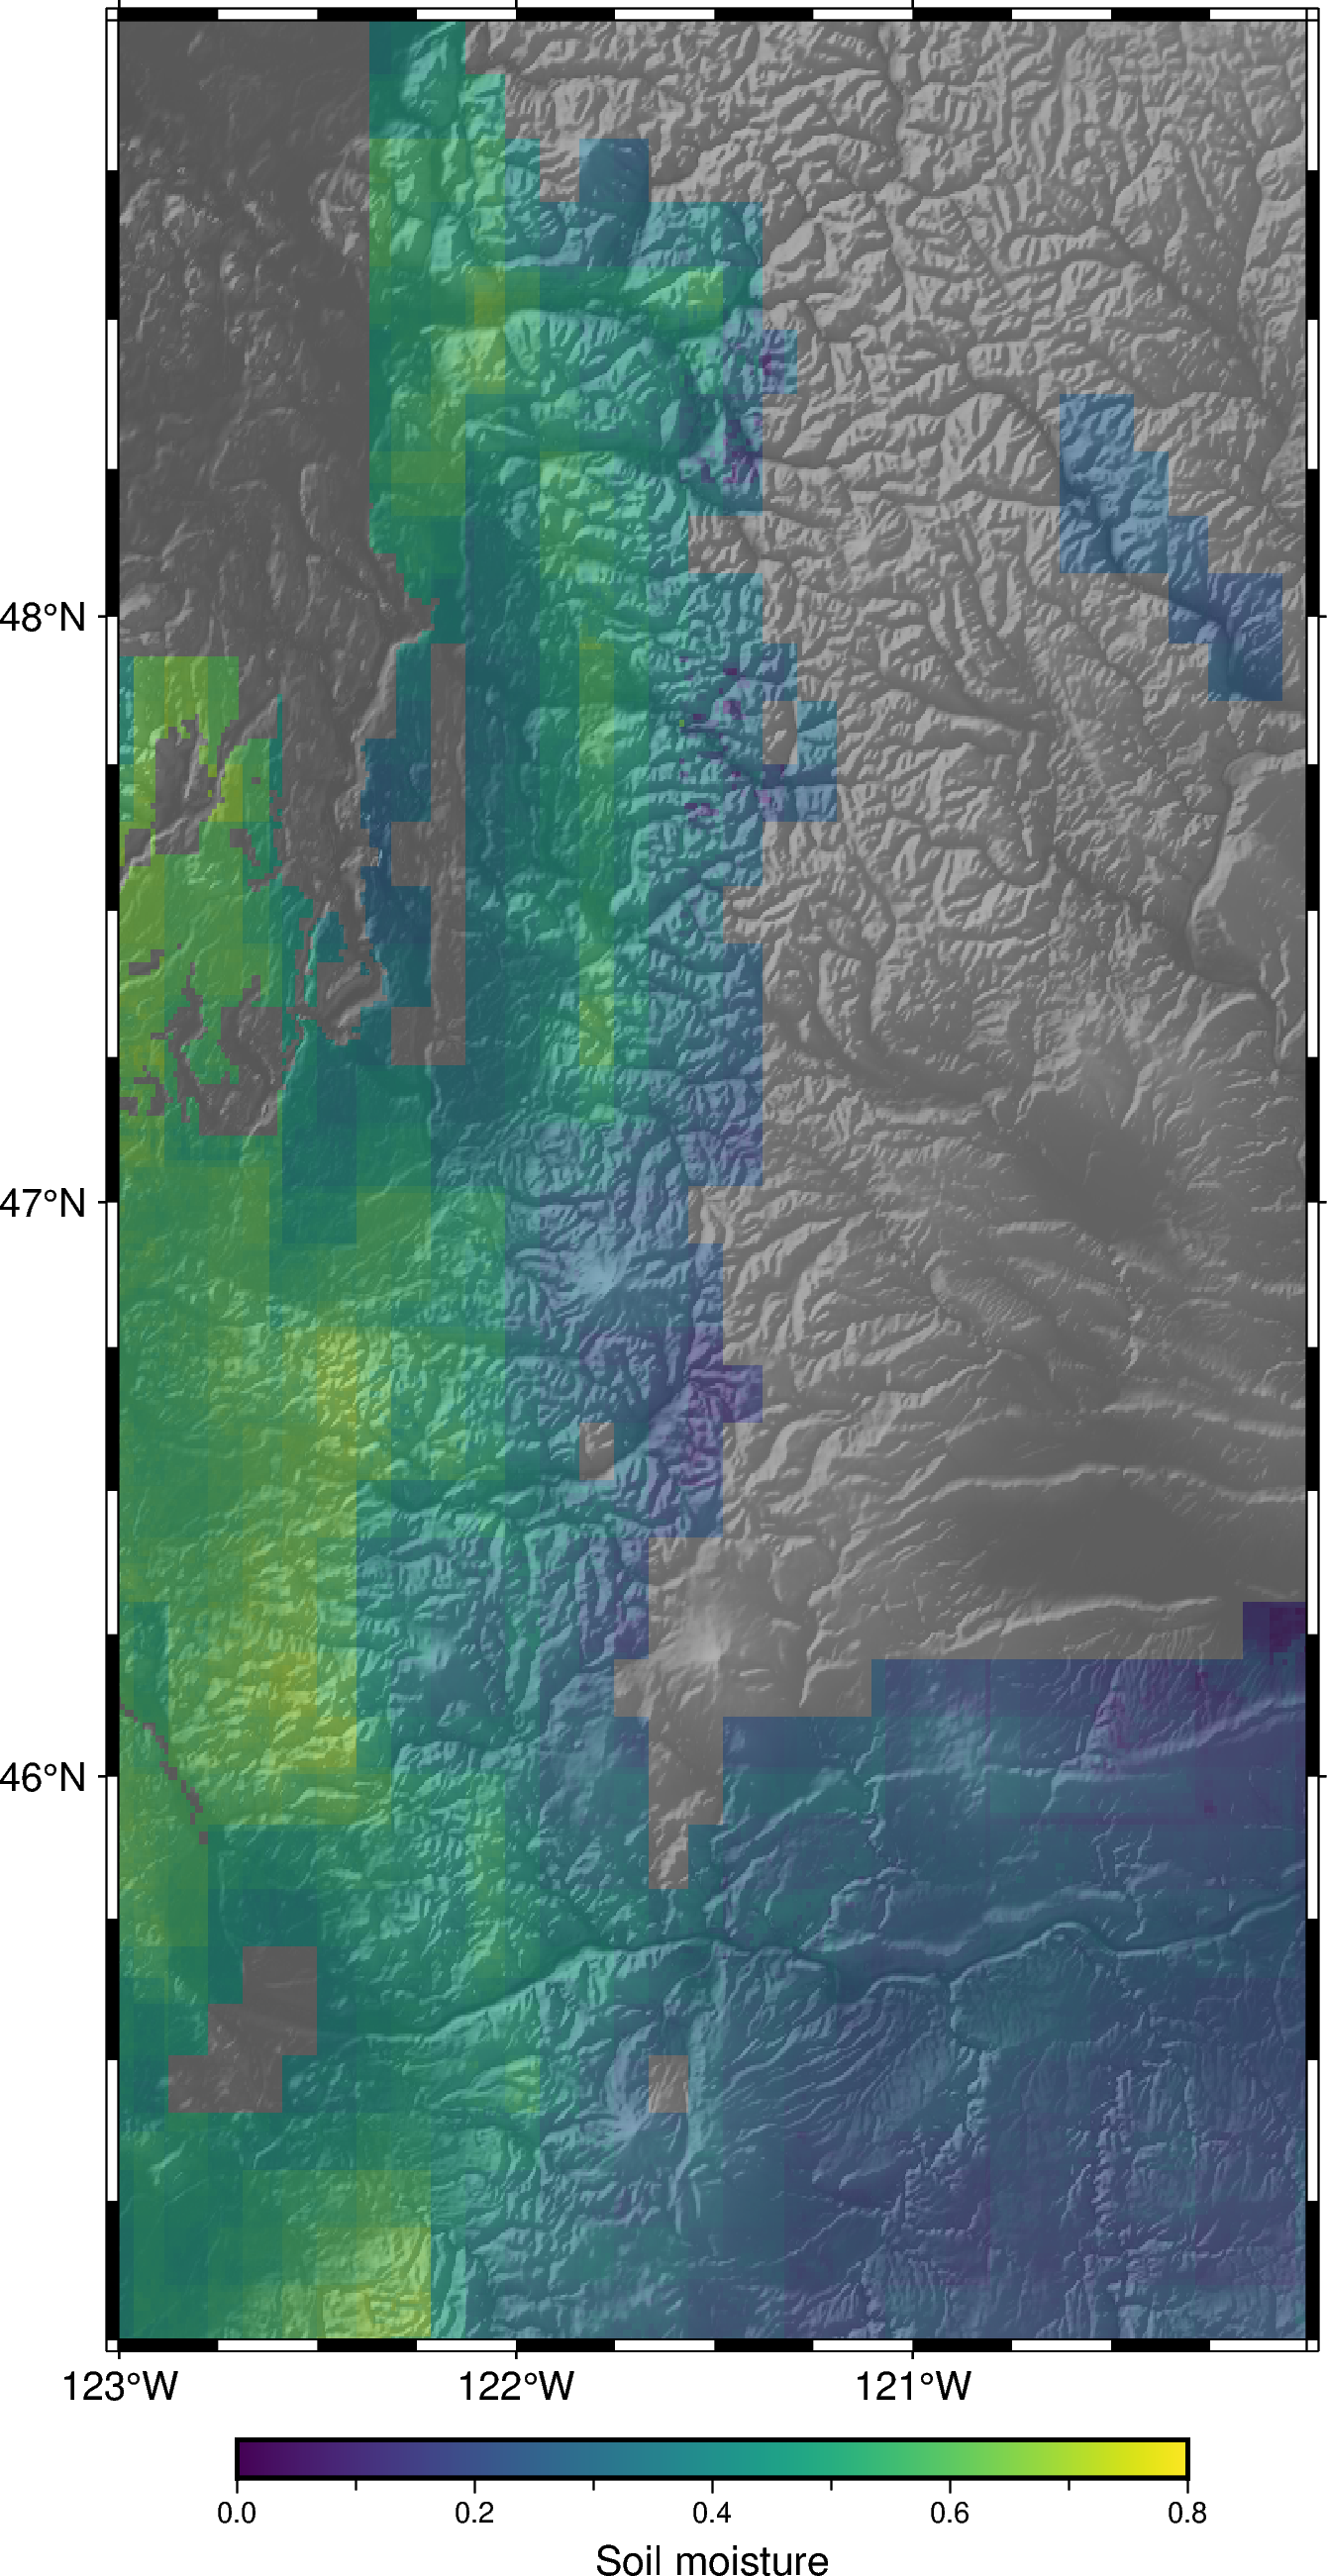

In [26]:
import pygmt

# -----------------------------
# Reproject SMAP raster to lat/lon
# -----------------------------
sm_ll = sm_clip.rio.reproject("EPSG:4326")

# Rename coordinates so PyGMT understands them
sm_ll = sm_ll.rename({"x": "lon", "y": "lat"})

# Save temporary grid
sm_file = "soil_moisture_temp.nc"
sm_ll.to_netcdf(sm_file)

# -----------------------------
# Define region
# -----------------------------
xmin = float(sm_ll.lon.min())
xmax = float(sm_ll.lon.max())
ymin = float(sm_ll.lat.min())
ymax = float(sm_ll.lat.max())

region = [xmin, xmax, ymin, ymax]
projection = "M4i"

# -----------------------------
# Load DEM
# -----------------------------
dem = pygmt.datasets.load_earth_relief(
    resolution="15s",
    region=region
)

# Hillshade
hillshade = pygmt.grdgradient(
    dem,
    azimuth=315,
    normalize="t1"
)

# -----------------------------
# Create figure
# -----------------------------
fig = pygmt.Figure()

# Hillshade background
fig.grdimage(
    grid=dem,
    region=region,
    projection=projection,
    shading=hillshade,
    cmap="gray"
)

# Soil moisture colormap
pygmt.makecpt(
    cmap="viridis",
    series=[0, 0.8],
    background=True,
)

# Overlay soil moisture
fig.grdimage(
    grid=sm_file,
    region=region,
    projection=projection,
    cmap=True,
    transparency=40
)

fig.basemap(frame="af")

fig.colorbar(frame="af+lSoil moisture")

fig.show()

In [57]:
# sm_clip_Rainier = soil_moisture.rio.clip_box(
#     minx=-121.936980556,
#     miny=46.7,
#     maxx=-121.521062714,
#     maxy=47,
#     crs="EPSG:4326"
# )

sm_clip_Rainier = soil_moisture.rio.clip_box(
    minx=-122,
    miny=46.7,
    maxx=-121.5,
    maxy=47,
    crs="EPSG:4326"
)

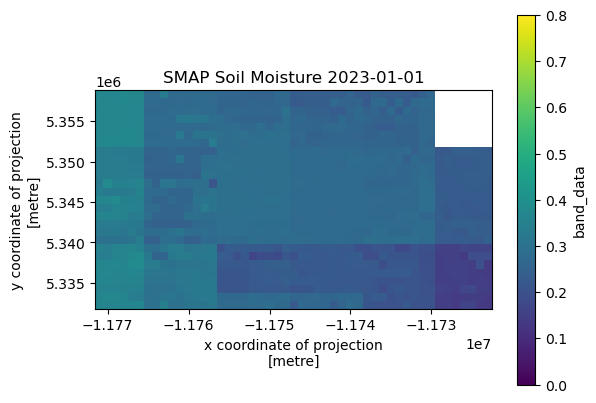

In [58]:
sm_clip_Rainier.plot(vmin=0, vmax=0.8)
plt.title("SMAP Soil Moisture 2023-01-01")
plt.gca().set_aspect('equal')
plt.show()

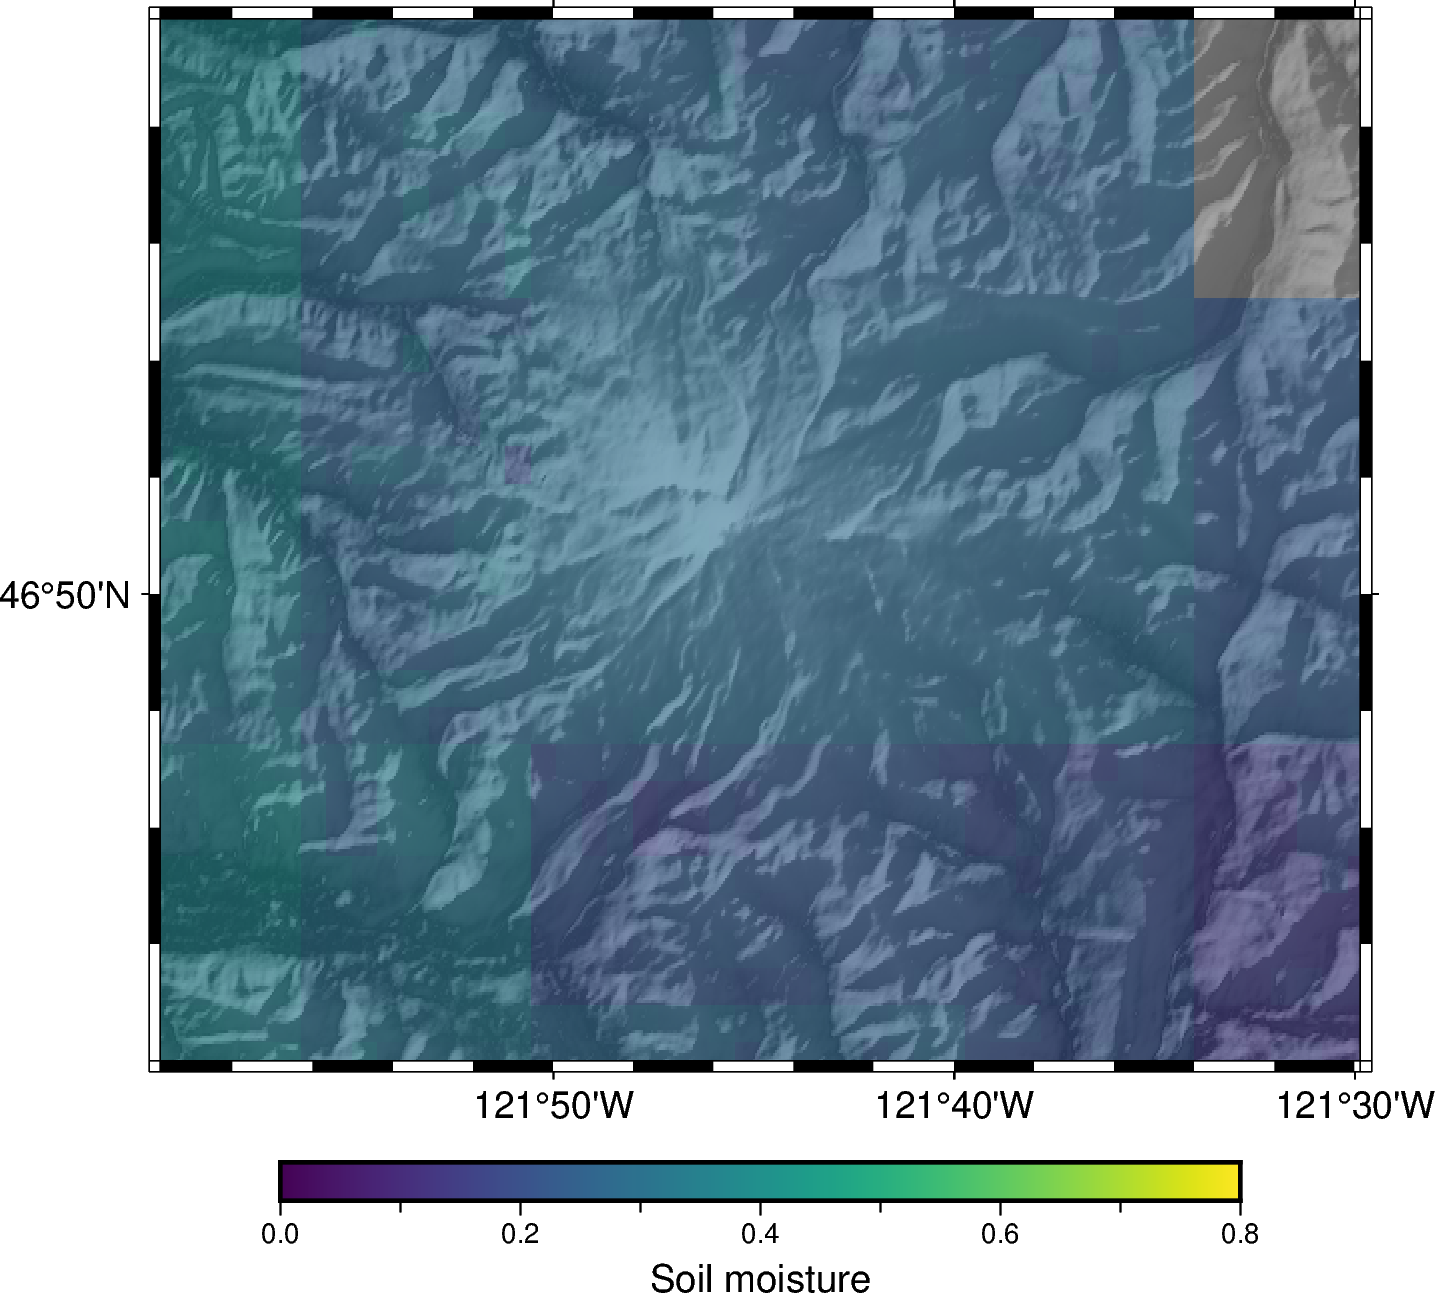

In [59]:
import pygmt

# -----------------------------
# Reproject SMAP raster to lat/lon
# -----------------------------
sm_ll = sm_clip_Rainier.rio.reproject("EPSG:4326")

# Rename coordinates so PyGMT understands them
sm_ll = sm_ll.rename({"x": "lon", "y": "lat"})

# Save temporary grid
sm_file = "soil_moisture_temp.nc"
sm_ll.to_netcdf(sm_file)

# -----------------------------
# Define region
# -----------------------------
xmin = float(sm_ll.lon.min())
xmax = float(sm_ll.lon.max())
ymin = float(sm_ll.lat.min())
ymax = float(sm_ll.lat.max())

region = [xmin, xmax, ymin, ymax]
projection = "M4i"

# -----------------------------
# Load DEM
# -----------------------------
dem = pygmt.datasets.load_earth_relief(
    resolution="03s",
    region=region
)

# Hillshade
hillshade = pygmt.grdgradient(
    dem,
    azimuth=315,
    normalize="t1"
)

# -----------------------------
# Create figure
# -----------------------------
fig = pygmt.Figure()

# Hillshade background
fig.grdimage(
    grid=dem,
    region=region,
    projection=projection,
    shading=hillshade,
    cmap="gray"
)

# Soil moisture colormap
pygmt.makecpt(
    cmap="viridis",
    series=[0, 0.8],
    background=True,
)

# Overlay soil moisture
fig.grdimage(
    grid=sm_file,
    region=region,
    projection=projection,
    cmap=True,
    transparency=40
)

fig.basemap(frame="af")

fig.colorbar(frame="af+lSoil moisture")

fig.show()

### Cut the data and save

In [1]:
import xarray as xr
import rioxarray
import numpy as np
import pandas as pd
import glob
from pathlib import Path

# -----------------------------
# Parameters
# -----------------------------
region_bbox = {
    "minx": -122. - 1e-2,
    "miny": 46.7 - 1e-2,
    "maxx": -121.5 + 1e-2,
    "maxy": 47. + 1e-2
}
data_dir = "/Volumes/optoDAS/Rainier/SMAP/"
output_file = "/Volumes/optoDAS/Rainier/SMAP_Rainier_2023_2024.nc"

files = sorted(glob.glob(data_dir + "NSIDC-0779_EASE2_G1km_SMAP_SM_DS_*.tif"))

# container for valid rasters
data_list = []
time_list = []

# -----------------------------
# Open dataset
# -----------------------------
for fp in files:
    sm = rioxarray.open_rasterio(fp).sel(band=1)

    sm.rio.write_crs("EPSG:6933", inplace=True)

    sm_clip = sm.rio.clip_box(
        minx=region_bbox["minx"],
        miny=region_bbox["miny"],
        maxx=region_bbox["maxx"],
        maxy=region_bbox["maxy"],
        crs="EPSG:4326"
    )

    # -----------------------------
    # Check valid data fraction
    # -----------------------------
    n_total = sm_clip.size
    n_nan = np.isnan(sm_clip.values).sum()
    valid_fraction = 1 - (n_nan / n_total)

    if valid_fraction >= 0.9:
        # -----------------------------
        # Save to NetCDF with time info
        # -----------------------------
        # Extract date from filename
        date_str = Path(fp).stem.split("_")[-1]
        time = pd.to_datetime(date_str, format="%Y%m%d")

        sm_clip = sm_clip.rio.reproject("EPSG:4326")

        data_list.append(sm_clip)
        time_list.append(time)

        print(f"Accepted {date_str} ({valid_fraction:.2%} valid)")

    else:
        print(f"Skipped {date_str} ({valid_fraction:.2%} valid)")

Accepted 20230101 (95.67% valid)
Skipped 20230101 (0.00% valid)
Skipped 20230101 (30.83% valid)
Accepted 20230104 (95.67% valid)
Skipped 20230104 (0.00% valid)
Accepted 20230106 (95.67% valid)
Skipped 20230106 (0.00% valid)
Skipped 20230106 (0.00% valid)
Accepted 20230109 (95.67% valid)
Skipped 20230109 (0.00% valid)
Skipped 20230109 (32.86% valid)
Accepted 20230112 (95.67% valid)
Skipped 20230112 (0.00% valid)
Skipped 20230112 (73.50% valid)
Accepted 20230115 (100.00% valid)
Skipped 20230115 (0.00% valid)
Accepted 20230117 (98.17% valid)
Skipped 20230117 (0.00% valid)
Skipped 20230117 (58.28% valid)
Accepted 20230120 (100.00% valid)
Skipped 20230120 (0.00% valid)
Accepted 20230122 (95.67% valid)
Skipped 20230122 (57.47% valid)
Skipped 20230122 (0.00% valid)
Accepted 20230125 (94.25% valid)
Skipped 20230125 (0.00% valid)
Skipped 20230125 (7.30% valid)
Accepted 20230128 (95.67% valid)
Skipped 20230128 (0.00% valid)
Accepted 20230130 (94.86% valid)
Accepted 20230131 (95.67% valid)
Skippe

In [2]:
# concatenate along time dimension
soil_moisture_ts = xr.concat(data_list, dim="time")

# assign time coordinate
soil_moisture_ts = soil_moisture_ts.assign_coords(time=time_list)

# rename dimensions (optional but nice)
soil_moisture_ts = soil_moisture_ts.rename({"x": "lon", "y": "lat"})

# assign variable name
soil_moisture_ts.name = "soil_moisture"

# save dataset
soil_moisture_ts.to_netcdf(output_file, mode="w")

print("Saved", output_file)

Saved /Volumes/optoDAS/Rainier/SMAP_Rainier_2023_2024.nc


### Load saved file and plot

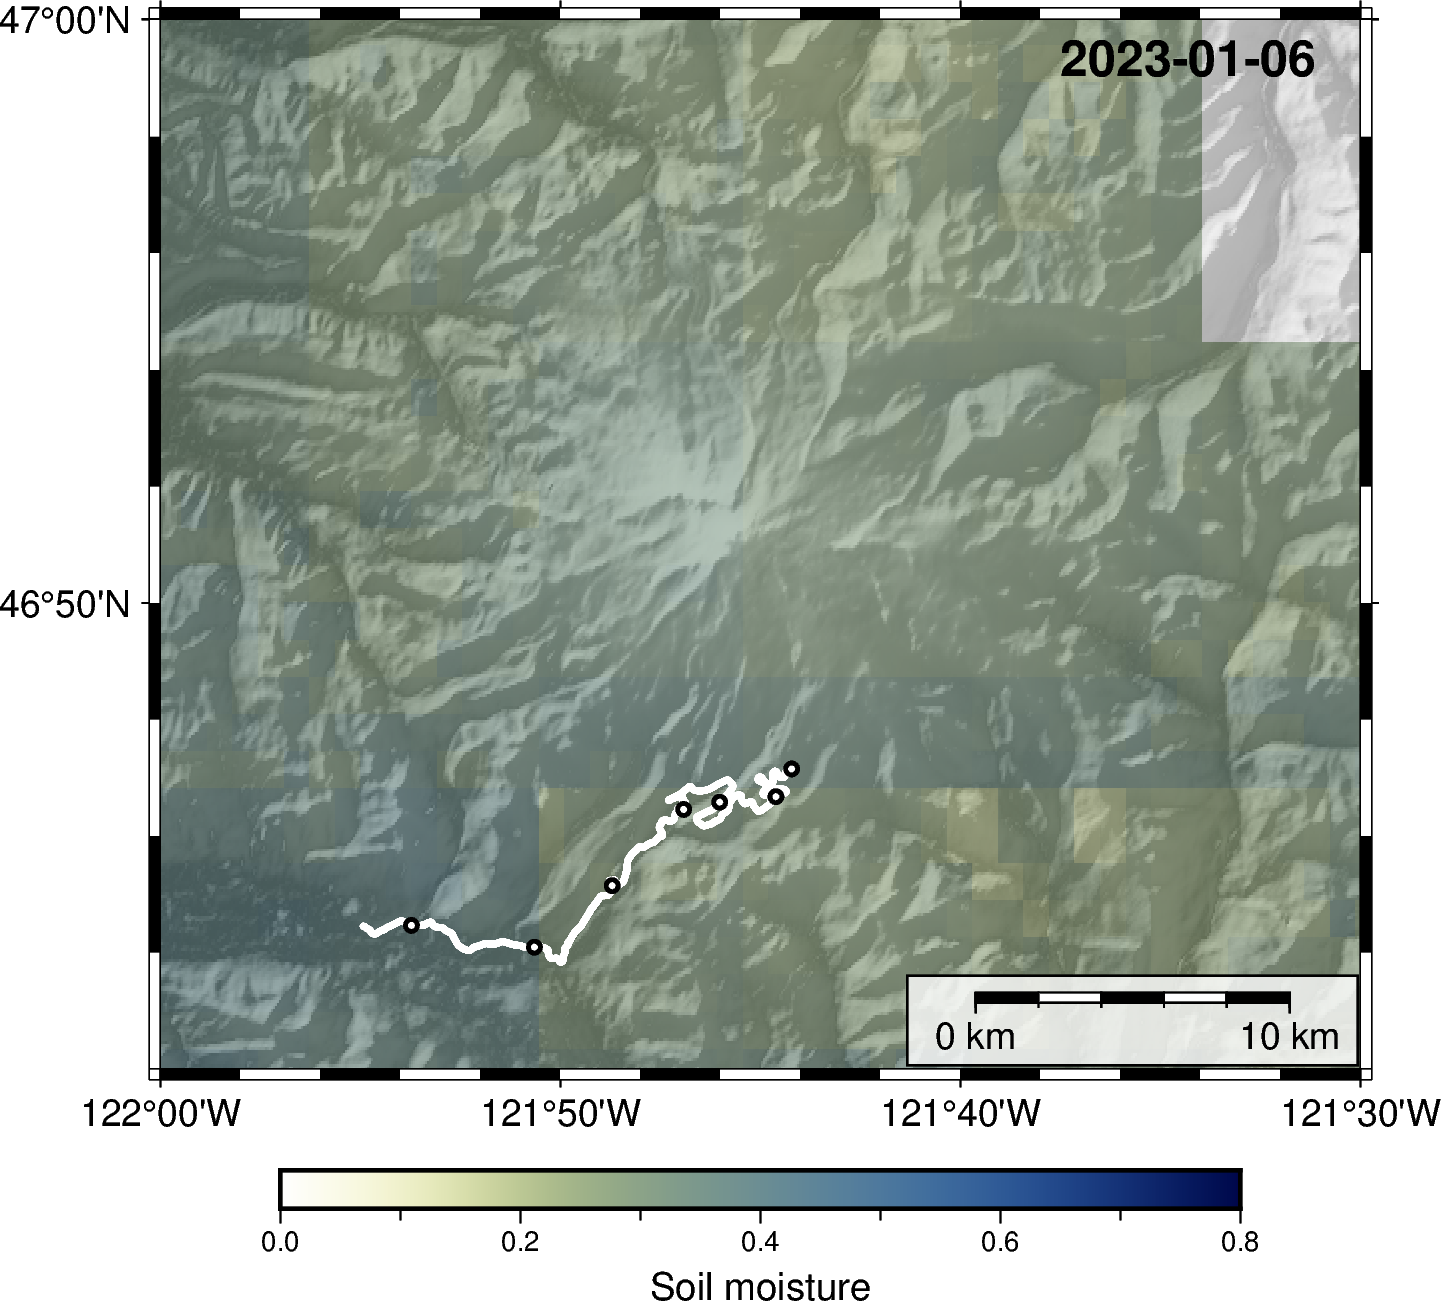

In [30]:
import pygmt
import xarray as xr
import pandas as pd

df = pd.read_csv("/Users/koepflma/Desktop/cascade/MtRainier/fiber_rout/Paradise2NisquallyEntrace_Channels.csv")
df = df.dropna(subset=["Latitude [°]", "Longitude [°]"])

ds = xr.open_dataset("/Volumes/optoDAS/Rainier/SMAP_Rainier_2023_2024.nc")
sm = ds["soil_moisture"].isel(time=2)

date_str = str(sm.time.values)[:10]

xmax = -121.5
xmin = -122.
ymax = 47.
ymin = 46.7

region = [xmin, xmax, ymin, ymax]


projection = "M4i"

dem = pygmt.datasets.load_earth_relief(
    resolution="03s",
    region=region
)

hillshade = pygmt.grdgradient(
    dem,
    azimuth=315,
    normalize="t1"
)

fig = pygmt.Figure()

fig.grdimage(
    grid=dem,
    region=region,
    projection=projection,
    shading=hillshade,
    cmap="gray"
)

pygmt.makecpt(
    cmap="davos",
    reverse=True,
    series=[0,0.8],
    background=True
)

fig.grdimage(
    grid=sm,
    region=region,
    projection=projection,
    cmap=True,
    transparency=40
)

fig.text(
    text=date_str,
    x=xmax - 0.25*(xmax-xmin),
    y=ymax - 0.02*(ymax-ymin),
    font="12p,Helvetica-Bold,black",
    justify="TL"
)

# All channels: small white dots
fig.plot(x=df['Longitude [°]'], y=df['Latitude [°]'], style="c0.05c", pen="0.1p,white")
# Highlight every 500th channel
df_lbl = df[df['Channel'] % 500 == 0]
fig.plot(
    x=df_lbl['Longitude [°]'],
    y=df_lbl['Latitude [°]'],
    style="c0.1c",
    pen="1.0p,black"
)
fig.basemap(frame="af")
fig.colorbar(frame="af+lSoil moisture")

# Add map scale
fig.basemap(map_scale="jBR+w10k+o0.6c/0.47c+f+ukm", box="+gwhite@20+p0.5p,black")

fig.show()

### Frames for mp4

In [31]:
from tqdm import tqdm
import xarray as xr
import pandas as pd
import pygmt
from pathlib import Path

In [33]:
# -----------------------------
# Define GIF output and range
# -----------------------------
ds = xr.open_dataset("/Volumes/optoDAS/Rainier/SMAP_Rainier_2023_2024.nc")
gif_file = Path("/Users/koepflma/Desktop/cascade/MtRainier/weather/SMAP_MtRainier_zoom.gif")
start_idx = 0
end_idx = len(ds["time"])

df = pd.read_csv("/Users/koepflma/Desktop/cascade/MtRainier/fiber_rout/Paradise2NisquallyEntrace_Channels.csv")
df = df.dropna(subset=["Latitude [°]", "Longitude [°]"])

# -----------------------------
# Define region and DEM
# -----------------------------
# small sample slice to get region
xmax = -121.5
xmin = -122.
ymax = 47.
ymin = 46.7

region = [xmin, xmax, ymin, ymax]

# Load DEM once (big, only needs to be done once)
dem = pygmt.datasets.load_earth_relief(resolution="03s", region=region)
hillshade = pygmt.grdgradient(dem, azimuth=315, normalize="t1")

# -----------------------------
# Loop over time to make GIF frames
# -----------------------------
for t_idx in tqdm(range(start_idx, end_idx)):
    # pick time slice
    sm = ds["soil_moisture"].isel(time=t_idx)
    
    # date string
    date_str = str(sm.time.values)[:10]
    
    # start PyGMT figure
    fig = pygmt.Figure()
    
    # Base hillshade
    fig.grdimage(
        grid=dem,
        region=region,
        projection="M4i",
        shading=hillshade,
        cmap="gray"
    )

    # Map frame
    fig.basemap(frame="af")

    # Overlay soil moisture with colormap
    pygmt.makecpt(cmap="davos", series=[0, 0.8, 0.1], reverse=True)
    fig.grdimage(
        grid=sm,
        region=region,
        projection="M4i",
        cmap=True,
        transparency=50
    )

    # Colorbar
    fig.colorbar(frame='af+lSoil moisture')
    
    # Date label (top-left)
    fig.text(
        text=date_str,
        x=xmax - 0.25*(xmax-xmin),
        y=ymax - 0.02*(ymax-ymin),
        font="12p,Helvetica-Bold,black",
        justify="TL"
    )
    
    # Fiber points
    fig.plot(x=df['Longitude [°]'], y=df['Latitude [°]'], style="c0.05c", pen="0.1p,white")
    df_lbl = df[df['Channel'] % 500 == 0]
    fig.plot(x=df_lbl['Longitude [°]'], y=df_lbl['Latitude [°]'], style="c0.15c", pen="1.0p,black")
    
    fig.basemap(map_scale="jBR+w10k+o0.6c/0.47c+f+ukm", box="+gwhite@20+p0.5p,black")
    
    fig.savefig(f"/Users/koepflma/Desktop/cascade/MtRainier/weather/SMAP_gif/SMAP_{date_str}.png", dpi=150)



  1%|          | 1/174 [00:00<01:17,  2.23it/s]

100%|██████████| 174/174 [01:07<00:00,  2.59it/s]


### Assign SMAP soil moisture to channels

In [26]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

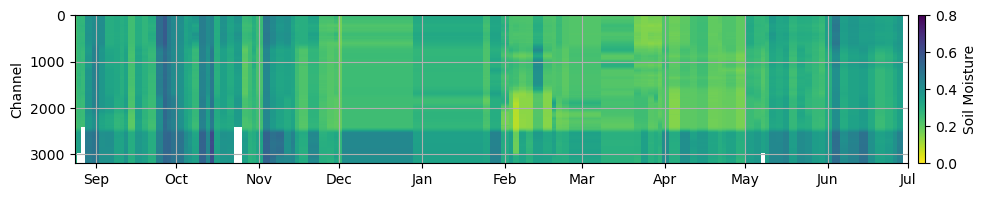

In [27]:
ds_loaded = xr.open_dataset("/Volumes/optoDAS/Rainier/SMAP_Rainier_2023_2024.nc")

df = pd.read_csv("/Users/koepflma/Desktop/cascade/MtRainier/fiber_rout/Paradise2NisquallyEntrace_Channels.csv")
df = df.dropna(subset=["Latitude [°]", "Longitude [°]"])

lats = xr.DataArray(df['Latitude [°]'].values, dims="channel")
lons = xr.DataArray(df['Longitude [°]'].values, dims="channel")

data = ds_loaded["soil_moisture"].interp(lat=lats, lon=lons)  # convert to meters

fig, ax = plt.subplots(figsize=(6.4*2,4.8*0.4))

# --- base SWE image ---
pcm = ax.pcolormesh(
    data.time.values,
    np.arange(len(lats)),
    data.T,
    shading="auto",
    vmin=0, vmax=0.8,
    cmap="viridis_r"
)

fig.colorbar(pcm, ax=ax, pad=0.01, label="Soil Moisture")

# formatting
plt.grid()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(datetime.datetime(2023, 8, 24), datetime.datetime(2024, 7, 1))
ax.invert_yaxis()
ax.set_ylabel("Channel")

plt.show()


## STF SSM

https://www.usgs.gov/data/data-release-a-3-hour-1-km-surface-soil-moisture-dataset-contiguous-united-states-2015-2023

In [22]:
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt

# path to your file
fp = "/Volumes/optoDAS/Rainier/STF_SSM/December2023/VIP_1km_20231222T1330.tif"

# open dataset
ds = xr.open_dataset(fp, engine="rasterio")

# basic info
print(ds)              # overview (dims, coords, variables)
print(ds.rio.crs)    # coordinate reference system

<xarray.Dataset> Size: 105MB
Dimensions:      (band: 1, x: 4611, y: 2854)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 37kB -2.354e+06 -2.353e+06 ... 2.255e+06 2.256e+06
  * y            (y) float64 23kB 3.165e+06 3.164e+06 ... 3.131e+05 3.121e+05
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float64 105MB ...
EPSG:5070


In [23]:
soil_moisture = ds.band_data.sel(band=1)
soil_moisture

<xarray.DataArray 'band_data' (y: 2854, x: 4611)> Size: 105MB
[13159794 values with dtype=float64]
Coordinates:
  * y            (y) float64 23kB 3.165e+06 3.164e+06 ... 3.131e+05 3.121e+05
  * x            (x) float64 37kB -2.354e+06 -2.353e+06 ... 2.255e+06 2.256e+06
    band         int64 8B 1
    spatial_ref  int64 8B ...
Attributes:
    OVR_RESAMPLING_ALG:  NEAREST
    units:               m3/m3
    AREA_OR_POINT:       Area

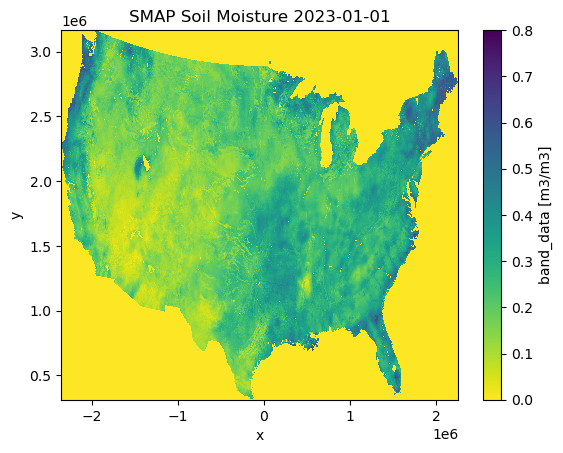

In [25]:
soil_moisture.plot(cmap="viridis_r", vmin=0, vmax=0.8)
plt.title("SMAP Soil Moisture 2023-01-01")
plt.show()

In [34]:
sm_clip_Rainier = soil_moisture.rio.clip_box(
    minx=-122,
    miny=46.7,
    maxx=-121.5,
    maxy=47,
    crs="EPSG:4326"
)

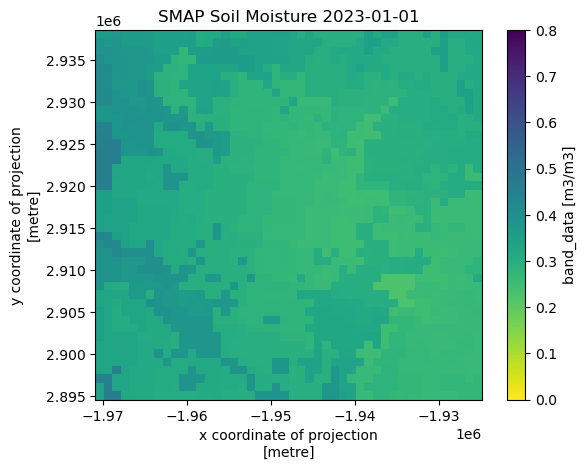

In [36]:
sm_clip_Rainier.plot(vmin=0, vmax=0.8, cmap="viridis_r")
plt.title("SMAP Soil Moisture 2023-01-01")
plt.gca().set_aspect('equal')
plt.show()

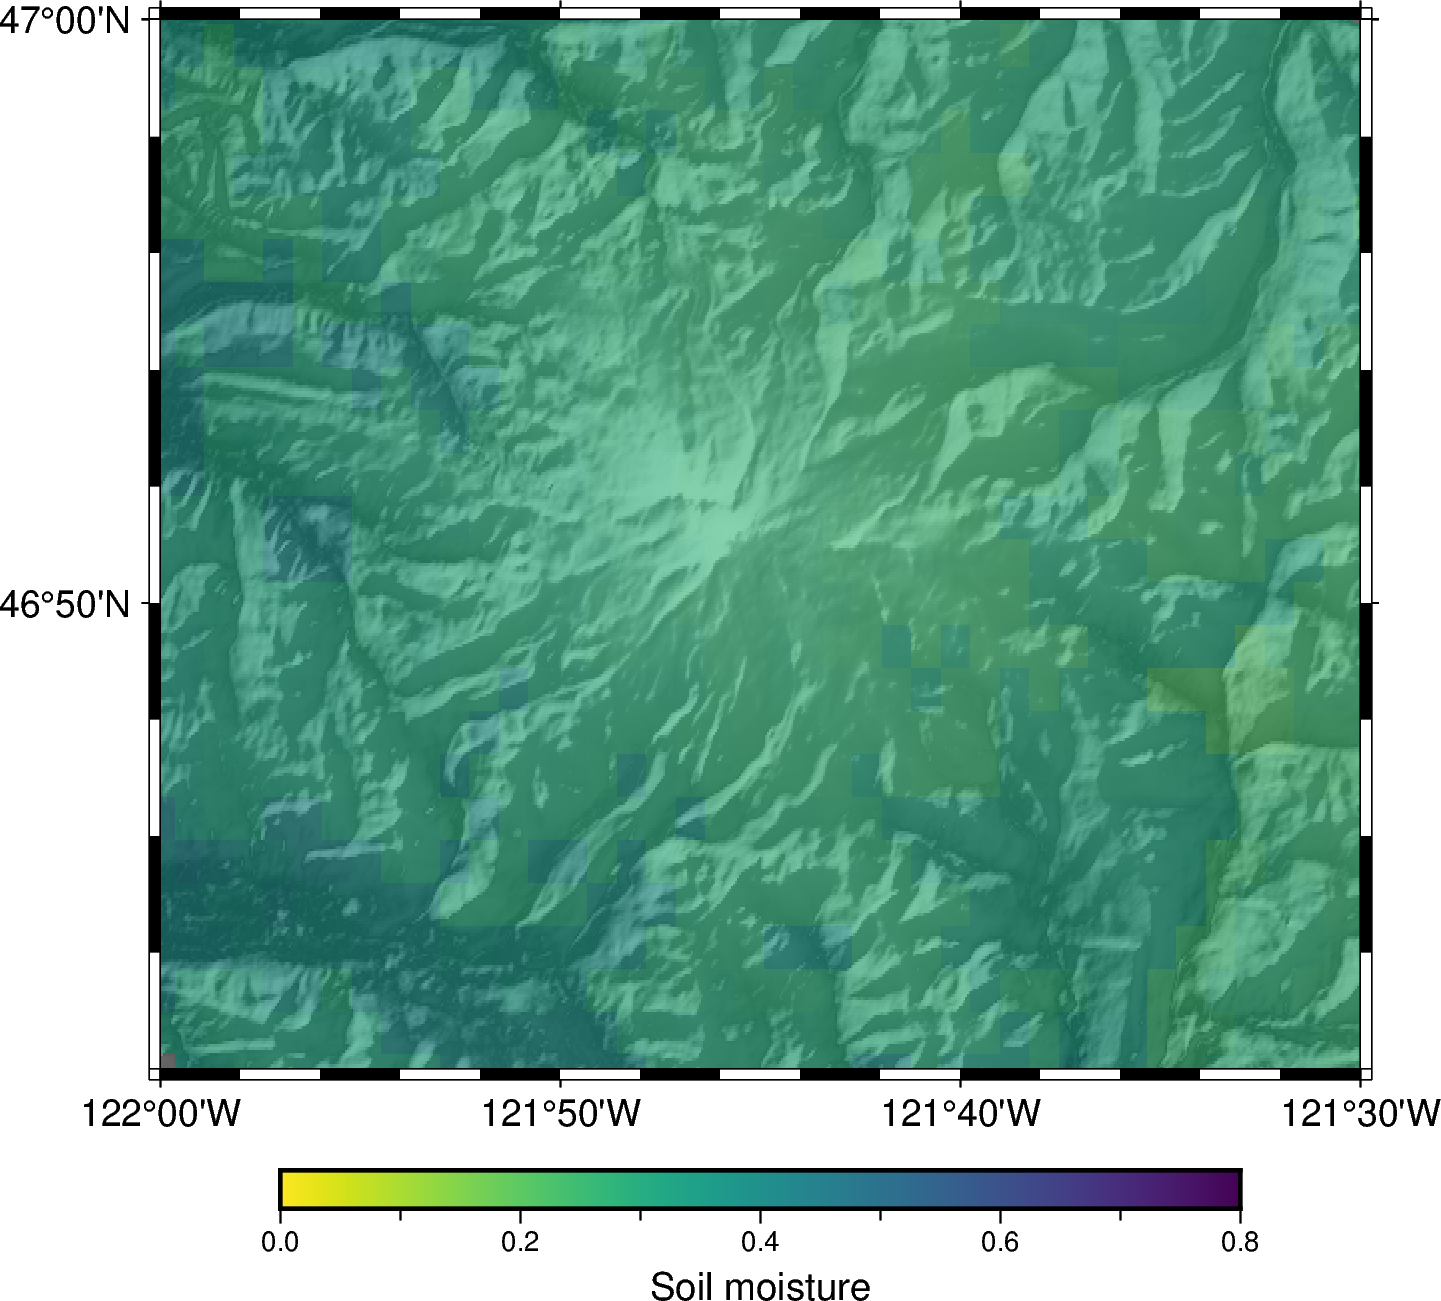

In [51]:
import pygmt

# -----------------------------
# Reproject SMAP raster to lat/lon
# -----------------------------
sm_ll = sm_clip_Rainier.rio.reproject("EPSG:4326")

# Rename coordinates so PyGMT understands them
sm_ll = sm_ll.rename({"x": "lon", "y": "lat"})

# Save temporary grid
sm_file = "soil_moisture_temp.nc"
sm_ll.to_netcdf(sm_file)

# -----------------------------
# Define region
# -----------------------------
# xmin = float(sm_ll.lon.min())
# xmax = float(sm_ll.lon.max())
# ymin = float(sm_ll.lat.min())
# ymax = float(sm_ll.lat.max())
xmax = -121.5
xmin = -122.
ymax = 47.
ymin = 46.7

region = [xmin, xmax, ymin, ymax]
projection = "M4i"

# -----------------------------
# Load DEM
# -----------------------------
dem = pygmt.datasets.load_earth_relief(
    resolution="03s",
    region=region
)

# Hillshade
hillshade = pygmt.grdgradient(
    dem,
    azimuth=315,
    normalize="t1"
)

# -----------------------------
# Create figure
# -----------------------------
fig = pygmt.Figure()

# Hillshade background
fig.grdimage(
    grid=dem,
    region=region,
    projection=projection,
    shading=hillshade,
    cmap="gray"
)

# Soil moisture colormap
pygmt.makecpt(
    cmap="viridis",
    reverse=True,
    series=[0, 0.8],
    background=True,
)

# Overlay soil moisture
fig.grdimage(
    grid=sm_file,
    region=region,
    projection=projection,
    cmap=True,
    transparency=40
)

fig.basemap(frame="af")

fig.colorbar(frame="af+lSoil moisture")

fig.show()

### Cut the data and save

In [58]:
import xarray as xr
import rioxarray
import numpy as np
import pandas as pd
import glob
from pathlib import Path

# -----------------------------
# Parameters
# -----------------------------
region_bbox = {
    "minx": -122. - 1e-2,
    "miny": 46.7 - 1e-2,
    "maxx": -121.5 + 1e-2,
    "maxy": 47. + 1e-2
}
data_dir = "/Volumes/optoDAS/Rainier/STF_SSM/December2023/"
output_file = "/Volumes/optoDAS/Rainier/STF_SSM_Rainier_2023.nc"

files = sorted(glob.glob(data_dir + "VIP_1km_*.tif"))

# container for valid rasters
data_list = []
time_list = []

# -----------------------------
# Open dataset
# -----------------------------
for fp in files:
    sm = rioxarray.open_rasterio(fp).sel(band=1)

    # sm.rio.write_crs("EPSG:6933", inplace=True)

    # sm = sm.rio.reproject("EPSG:4326")

    sm_clip = sm.rio.clip_box(
        minx=region_bbox["minx"],
        miny=region_bbox["miny"],
        maxx=region_bbox["maxx"],
        maxy=region_bbox["maxy"],
        crs="EPSG:4326"
    )

    # -----------------------------
    # Check valid data fraction
    # -----------------------------
    n_total = sm_clip.size
    n_nan = np.isnan(sm_clip.values).sum()
    valid_fraction = 1 - (n_nan / n_total)

    if valid_fraction >= 0.9:
        # -----------------------------
        # Save to NetCDF with time info
        # -----------------------------
        # Extract date from filename
        date_str = Path(fp).stem.split("_")[-1]
        time = pd.to_datetime(date_str, format="%Y%m%dT%H%M")

        sm_clip = sm_clip.rio.reproject("EPSG:4326")

        data_list.append(sm_clip)
        time_list.append(time)

        print(f"Accepted {date_str} ({valid_fraction:.2%} valid)")

    else:
        print(f"Skipped {date_str} ({valid_fraction:.2%} valid)")

Accepted 20231201T0130 (100.00% valid)
Accepted 20231201T0430 (100.00% valid)
Accepted 20231201T0730 (100.00% valid)
Accepted 20231201T1030 (100.00% valid)
Accepted 20231201T1330 (100.00% valid)
Accepted 20231201T1630 (100.00% valid)
Accepted 20231201T1930 (100.00% valid)
Accepted 20231201T2230 (100.00% valid)
Accepted 20231202T0130 (100.00% valid)
Accepted 20231202T0430 (100.00% valid)
Accepted 20231202T0730 (100.00% valid)
Accepted 20231202T1030 (100.00% valid)
Accepted 20231202T1330 (100.00% valid)
Accepted 20231202T1630 (100.00% valid)
Accepted 20231202T1930 (100.00% valid)
Accepted 20231202T2230 (100.00% valid)
Accepted 20231203T0130 (100.00% valid)
Accepted 20231203T0430 (100.00% valid)
Accepted 20231203T0730 (100.00% valid)
Accepted 20231203T1030 (100.00% valid)
Accepted 20231203T1330 (100.00% valid)
Accepted 20231203T1630 (100.00% valid)
Accepted 20231203T1930 (100.00% valid)
Accepted 20231203T2230 (100.00% valid)
Accepted 20231204T0130 (100.00% valid)
Accepted 20231204T0430 (1

In [60]:
# concatenate along time dimension
soil_moisture_ts = xr.concat(data_list, dim="time")

# assign time coordinate
soil_moisture_ts = soil_moisture_ts.assign_coords(time=time_list)

# rename dimensions (optional but nice)
soil_moisture_ts = soil_moisture_ts.rename({"x": "lon", "y": "lat"})

# assign variable name
soil_moisture_ts.name = "soil_moisture"

# save dataset
soil_moisture_ts.to_netcdf(output_file, mode="w")

print("Saved", output_file)

Saved /Volumes/optoDAS/Rainier/STF_SSM_Rainier_2023.nc


### Load saved file and plot

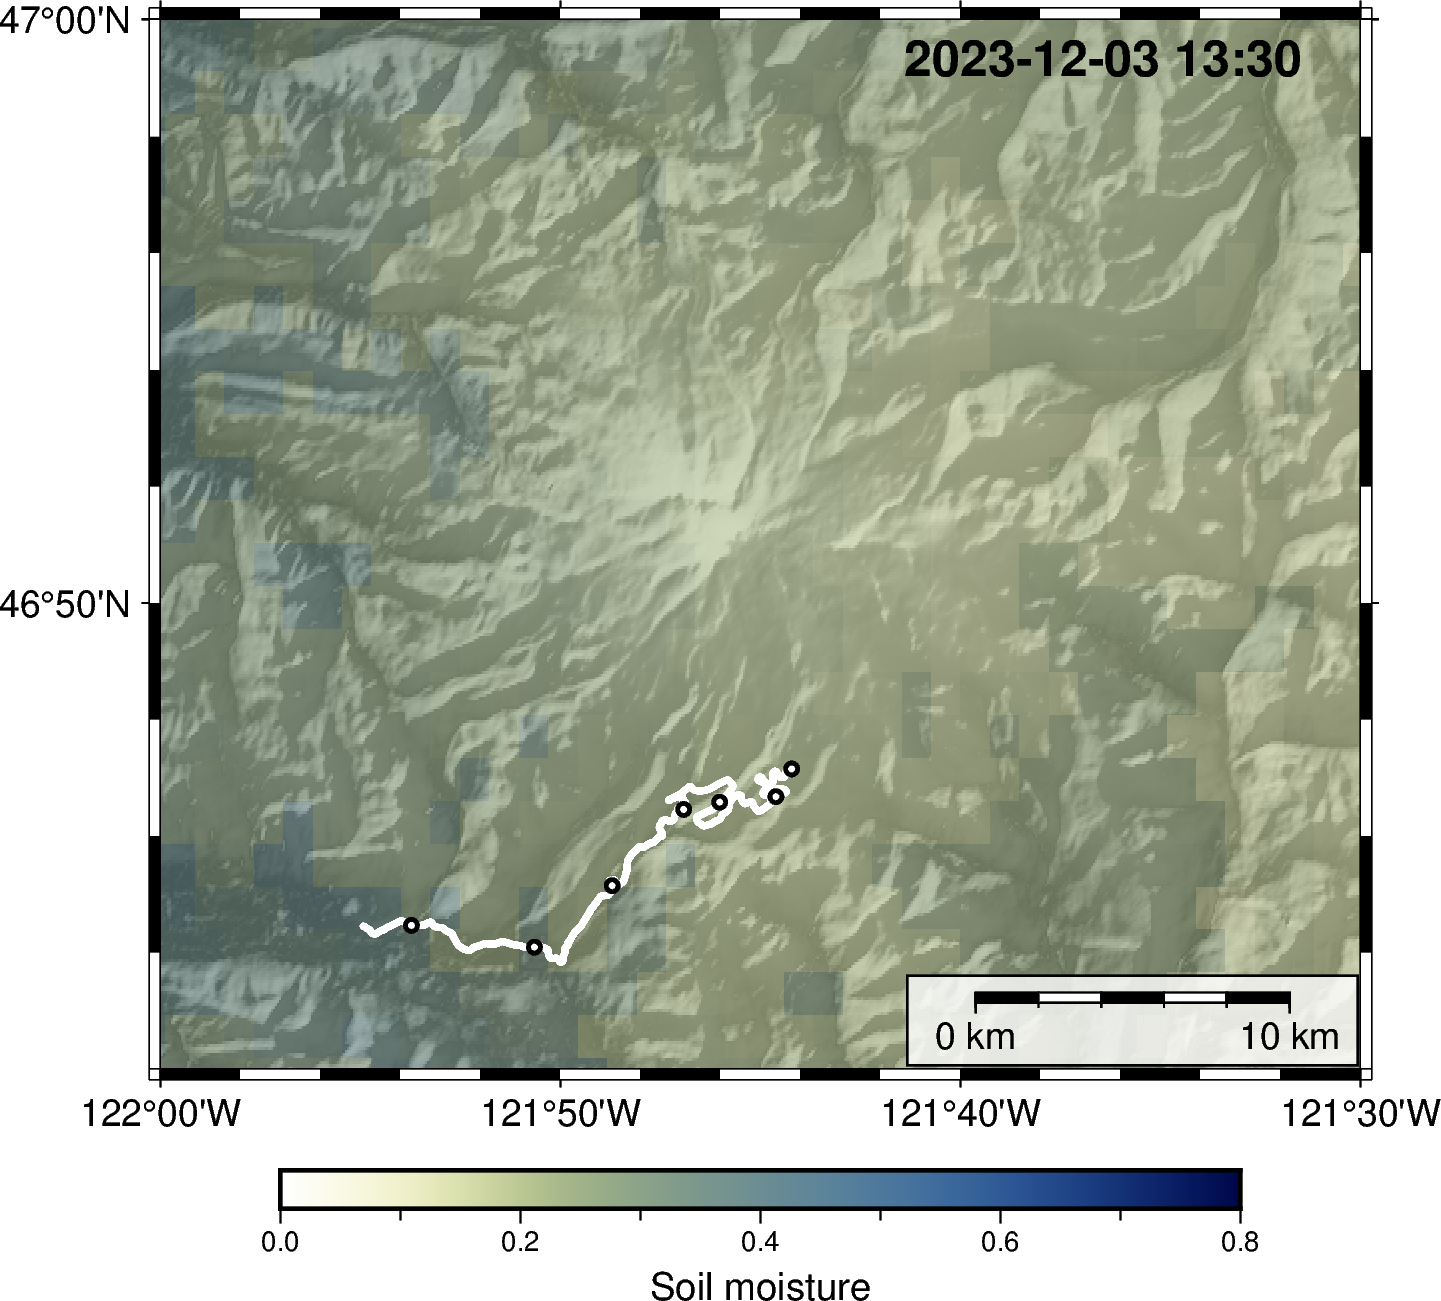

In [71]:
import pygmt
import xarray as xr
import pandas as pd

df = pd.read_csv("/Users/koepflma/Desktop/cascade/MtRainier/fiber_rout/Paradise2NisquallyEntrace_Channels.csv")
df = df.dropna(subset=["Latitude [°]", "Longitude [°]"])

ds = xr.open_dataset("/Volumes/optoDAS/Rainier/STF_SSM_Rainier_2023.nc")
sm = ds["soil_moisture"].isel(time=20)

date_str = str(sm.time.values)[:16]

xmax = -121.5
xmin = -122.
ymax = 47.
ymin = 46.7

region = [xmin, xmax, ymin, ymax]


projection = "M4i"

dem = pygmt.datasets.load_earth_relief(
    resolution="03s",
    region=region
)

hillshade = pygmt.grdgradient(
    dem,
    azimuth=315,
    normalize="t1"
)

fig = pygmt.Figure()

fig.grdimage(
    grid=dem,
    region=region,
    projection=projection,
    shading=hillshade,
    cmap="gray"
)

pygmt.makecpt(
    cmap="davos",
    reverse=True,
    series=[0,0.8],
    background=True
)

fig.grdimage(
    grid=sm,
    region=region,
    projection=projection,
    cmap=True,
    transparency=40
)

fig.text(
    text=f"{date_str[:10]} {date_str[11:16]}",
    x=xmax - 0.38*(xmax-xmin),
    y=ymax - 0.02*(ymax-ymin),
    font="12p,Helvetica-Bold,black",
    justify="TL"
)

# All channels: small white dots
fig.plot(x=df['Longitude [°]'], y=df['Latitude [°]'], style="c0.05c", pen="0.1p,white")
# Highlight every 500th channel
df_lbl = df[df['Channel'] % 500 == 0]
fig.plot(
    x=df_lbl['Longitude [°]'],
    y=df_lbl['Latitude [°]'],
    style="c0.1c",
    pen="1.0p,black"
)
fig.basemap(frame="af")
fig.colorbar(frame="af+lSoil moisture")

# Add map scale
fig.basemap(map_scale="jBR+w10k+o0.6c/0.47c+f+ukm", box="+gwhite@20+p0.5p,black")

fig.show()

### Frames for mp4

In [ ]:
from tqdm import tqdm
import xarray as xr
import pandas as pd
import pygmt
from pathlib import Path

In [72]:
# -----------------------------
# Define GIF output and range
# -----------------------------
ds = xr.open_dataset("/Volumes/optoDAS/Rainier/STF_SSM_Rainier_2023.nc")
start_idx = 0
end_idx = 5#len(ds["time"])

df = pd.read_csv("/Users/koepflma/Desktop/cascade/MtRainier/fiber_rout/Paradise2NisquallyEntrace_Channels.csv")
df = df.dropna(subset=["Latitude [°]", "Longitude [°]"])

# -----------------------------
# Define region and DEM
# -----------------------------
# small sample slice to get region
xmax = -121.5
xmin = -122.
ymax = 47.
ymin = 46.7

region = [xmin, xmax, ymin, ymax]

# Load DEM once (big, only needs to be done once)
dem = pygmt.datasets.load_earth_relief(resolution="03s", region=region)
hillshade = pygmt.grdgradient(dem, azimuth=315, normalize="t1")

# -----------------------------
# Loop over time to make GIF frames
# -----------------------------
for t_idx in tqdm(range(start_idx, end_idx)):
    # pick time slice
    sm = ds["soil_moisture"].isel(time=t_idx)
    
    # date string
    date_str = str(sm.time.values)[:16]
    
    # start PyGMT figure
    fig = pygmt.Figure()
    
    # Base hillshade
    fig.grdimage(
        grid=dem,
        region=region,
        projection="M4i",
        shading=hillshade,
        cmap="gray"
    )

    # Map frame
    fig.basemap(frame="af")

    # Overlay soil moisture with colormap
    pygmt.makecpt(cmap="davos", series=[0, 0.8, 0.1], reverse=True)
    fig.grdimage(
        grid=sm,
        region=region,
        projection="M4i",
        cmap=True,
        transparency=50
    )

    # Colorbar
    fig.colorbar(frame='af+lSoil moisture')
    
    # Date label (top-left)
    fig.text(
    text=f"{date_str[:10]} {date_str[11:16]}",
    x=xmax - 0.38*(xmax-xmin),
    y=ymax - 0.02*(ymax-ymin),
    font="12p,Helvetica-Bold,black",
    justify="TL"
)
    
    # Fiber points
    fig.plot(x=df['Longitude [°]'], y=df['Latitude [°]'], style="c0.05c", pen="0.1p,white")
    df_lbl = df[df['Channel'] % 500 == 0]
    fig.plot(x=df_lbl['Longitude [°]'], y=df_lbl['Latitude [°]'], style="c0.15c", pen="1.0p,black")
    
    fig.basemap(map_scale="jBR+w10k+o0.6c/0.47c+f+ukm", box="+gwhite@20+p0.5p,black")
    
    fig.savefig(f"/Users/koepflma/Desktop/cascade/MtRainier/weather/STF_SSM_gif/STF_SSM_{date_str}.png", dpi=150)



100%|██████████| 5/5 [00:02<00:00,  2.34it/s]
